# Module 08 — Differential Expression Analysis (v4)

This notebook visualizes pre-computed pseudobulk differential expression results
from `scripts/08_differential.py`. Pseudobulk aggregation (summing counts per
donor per cell type) avoids treating cells as independent observations, and
pyDESeq2 is used for statistical testing.

**Pipeline version:** v4 (scANVI-based, 12 modules)

**Data sources:**
- `results/differential/de_summary_table.tsv` — Summary of all comparisons
- `results/differential/skipped_comparisons.tsv` — Underpowered comparisons
- `results/differential/de_results_combined.tsv` — Full DE results
- `results/differential/volcano_plots/` — Volcano plots per comparison
- `results/differential/heatmaps/` — Heatmaps of top DE genes
- `results/differential/composition_analysis.tsv` — Cell type composition changes

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})

# ── Paths ──────────────────────────────────────────────────────────────────
BASE = Path('..').resolve()
RESULTS = BASE / 'results' / 'differential'
VOLCANO_DIR = RESULTS / 'volcano_plots'
HEATMAP_DIR = RESULTS / 'heatmaps'

print(f'Results directory: {RESULTS}')
print(f'Volcano plots:    {len(list(VOLCANO_DIR.glob("*.png")))} files')
print(f'Heatmaps:         {len(list(HEATMAP_DIR.glob("*.png")))} files')

Results directory: /home/ubuntu/lotz-ivd/results/differential
Volcano plots:    23 files
Heatmaps:         4 files


## DE Summary Table

Each row represents one powered comparison (cell type x condition pair). The
table shows the number of significantly up- and down-regulated genes per
comparison.

In [2]:
summary = pd.read_csv(RESULTS / 'de_summary_table.tsv', sep='\t')
print(f'Total powered comparisons: {len(summary)}')
print(f'Total significant genes (sum across comparisons): {summary["n_total"].sum()}')

display(summary.style.set_caption('Pseudobulk DE Summary — All Powered Comparisons'))

Total powered comparisons: 20
Total significant genes (sum across comparisons): 966


,cell_type,comparison,n_up,n_down,n_total
0,AF_inner,healthy_vs_degenerated_all,28,11,39
1,AF_inner,healthy_vs_degenerated_severe,35,17,52
2,AF_outer,healthy_vs_degenerated_all,3,3,6
3,AF_outer,healthy_vs_degenerated_mild,0,2,2
4,AF_outer,healthy_vs_degenerated_severe,39,19,58
5,AF_outer,mild_vs_severe,2,0,2
6,Fibrochondrocyte_chondroid,healthy_vs_degenerated_mild,0,2,2
7,Fibrochondrocyte_chondroid,healthy_vs_degenerated_severe,2,0,2
8,Fibrochondrocyte_chondroid,mild_vs_severe,8,6,14
9,Fibrochondrocyte_stressed,mild_vs_severe,11,3,14


In [3]:
# Unique significant genes across all comparisons
de_combined = pd.read_csv(RESULTS / 'de_results_combined.tsv', sep='\t')
sig = de_combined[(de_combined['padj'] < 0.05) & (de_combined['log2FC'].abs() > 0.5)]
print(f'Unique significant genes: {sig["gene"].nunique()}')
print(f'Total significant hits:   {len(sig)}')
print(f'\nCell types with DE results: {sig["cell_type"].nunique()}')
for ct in sorted(sig['cell_type'].unique()):
    n = sig[sig['cell_type'] == ct]['gene'].nunique()
    print(f'  {ct}: {n} genes')

Unique significant genes: 772
Total significant hits:   966

Cell types with DE results: 8
  AF_inner: 52 genes
  AF_outer: 62 genes
  Fibrochondrocyte_chondroid: 18 genes
  Fibrochondrocyte_stressed: 14 genes
  NP_fibrocartilaginous: 429 genes
  NP_mature_chondrocyte: 248 genes
  NP_notochordal: 12 genes
  unassigned: 11 genes


## Skipped (Underpowered) Comparisons

Comparisons that did not meet the minimum donor threshold (>= 3 donors per
group) are listed here with the reason for exclusion.

In [4]:
skipped = pd.read_csv(RESULTS / 'skipped_comparisons.tsv', sep='\t')
print(f'Skipped comparisons: {len(skipped)}')
display(skipped)

Skipped comparisons: 36


,comparison,reason
0,Fibrochondrocyte_fibroid | healthy_vs_degenera...,"Underpowered: 1 ref, 2 test (need >= 3)"
1,NP_stressed | healthy_vs_degenerated_all,"Underpowered: 1 ref, 1 test (need >= 3)"
2,Fibrochondrocyte_stressed | healthy_vs_degener...,"Underpowered: 1 ref, 11 test (need >= 3)"
3,unassigned | healthy_vs_degenerated_all,"Underpowered: 2 ref, 11 test (need >= 3)"
4,Pericyte_SMC | healthy_vs_degenerated_all,No valid samples with >= 50 cells
5,Macrophage_M2 | healthy_vs_degenerated_all,No valid samples with >= 50 cells
6,Fibrochondrocyte_fibroid | healthy_vs_degenera...,"Underpowered: 1 ref, 1 test (need >= 3)"
7,NP_stressed | healthy_vs_degenerated_mild,"Underpowered: 1 ref, 0 test (need >= 3)"
8,Fibrochondrocyte_stressed | healthy_vs_degener...,"Underpowered: 1 ref, 5 test (need >= 3)"
9,unassigned | healthy_vs_degenerated_mild,"Underpowered: 2 ref, 5 test (need >= 3)"


## Volcano Plots

Volcano plots show the relationship between fold change (x-axis) and
statistical significance (y-axis) for each comparison. Points colored by
significance threshold (|log2FC| > 0.5, padj < 0.05).

### Key resident cell type comparisons

**NP mature chondrocyte healthy vs degenerated mild**

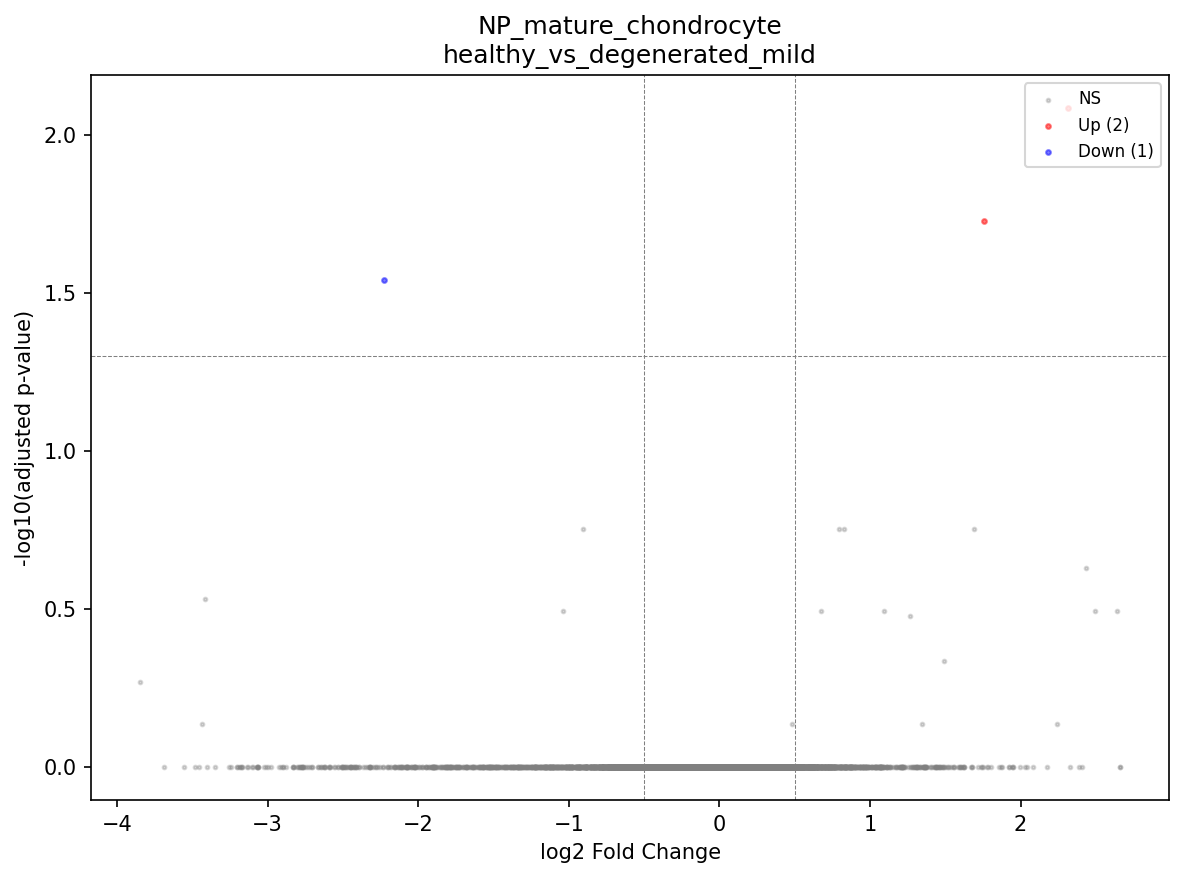

**NP mature chondrocyte healthy vs degenerated severe**

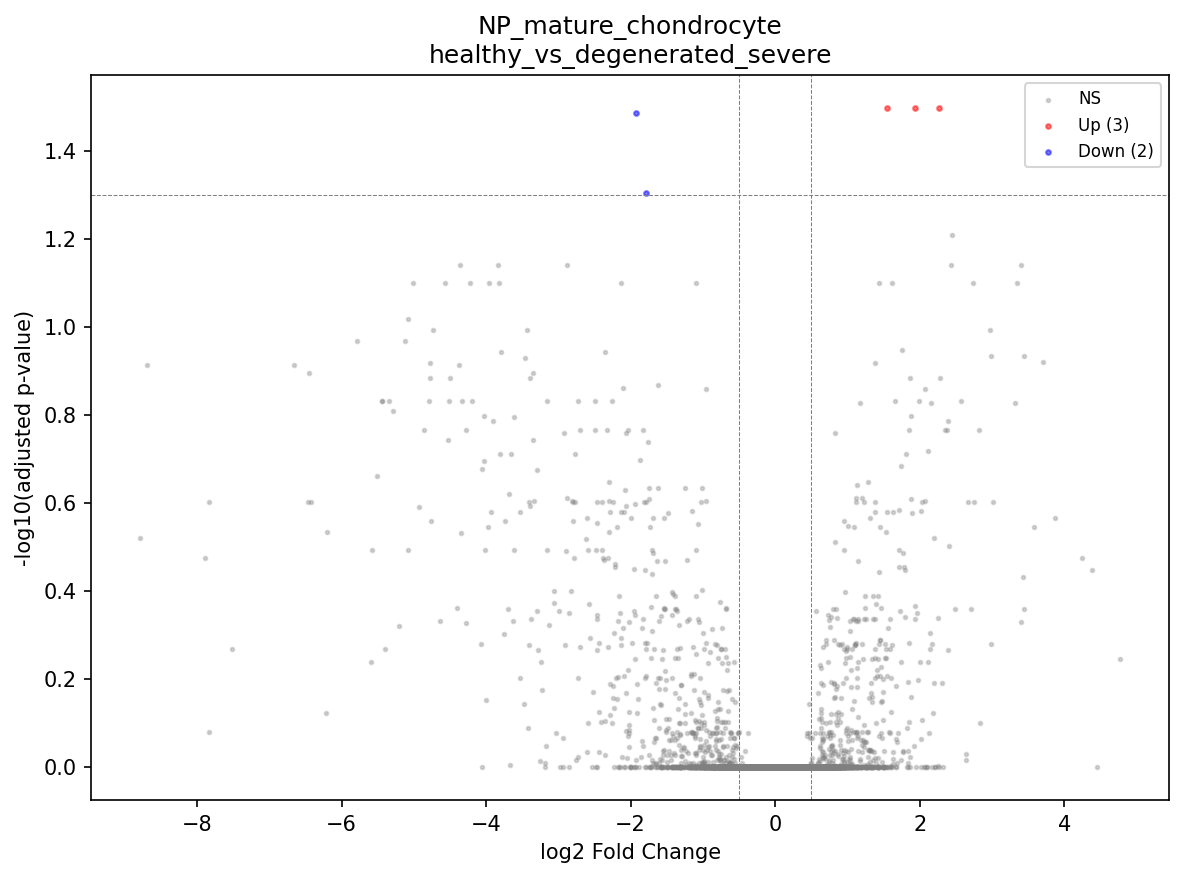

**NP fibrocartilaginous healthy vs degenerated all**

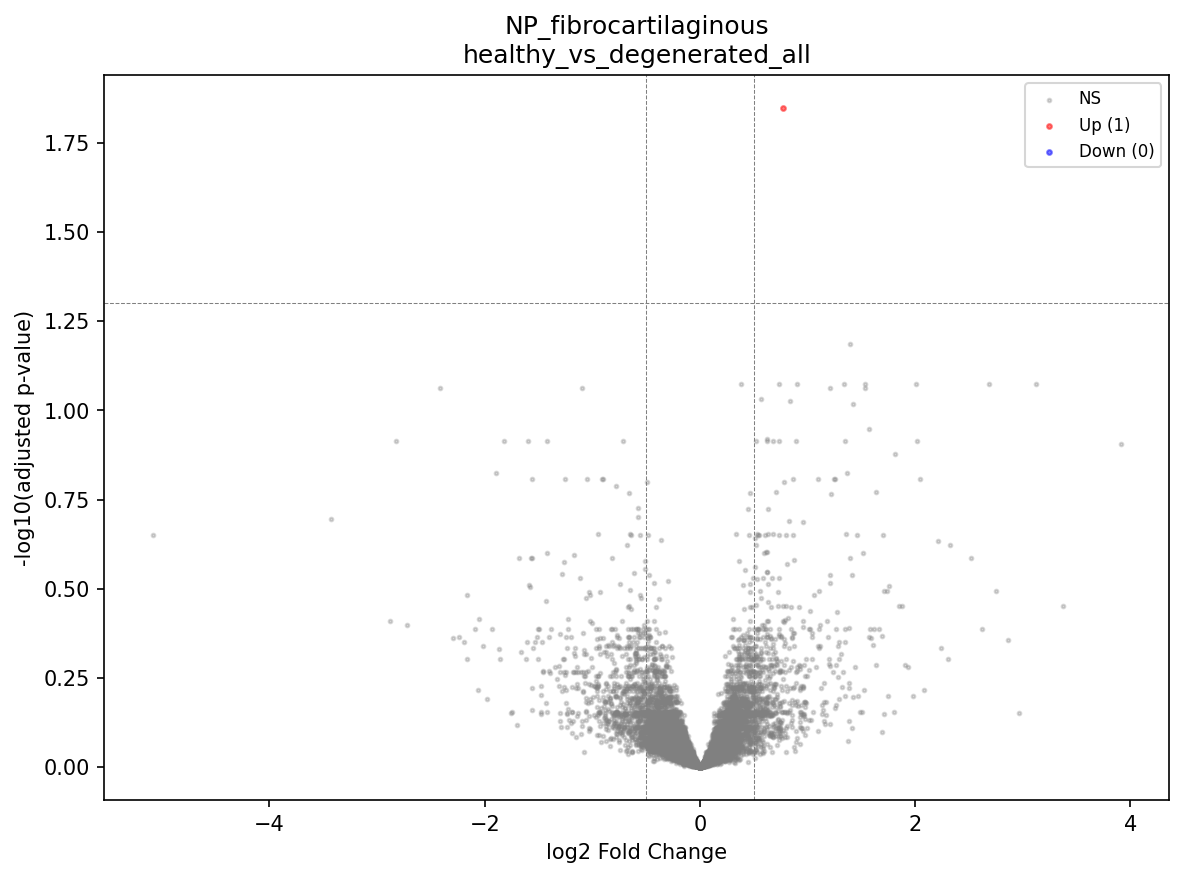

**NP fibrocartilaginous healthy vs degenerated mild**

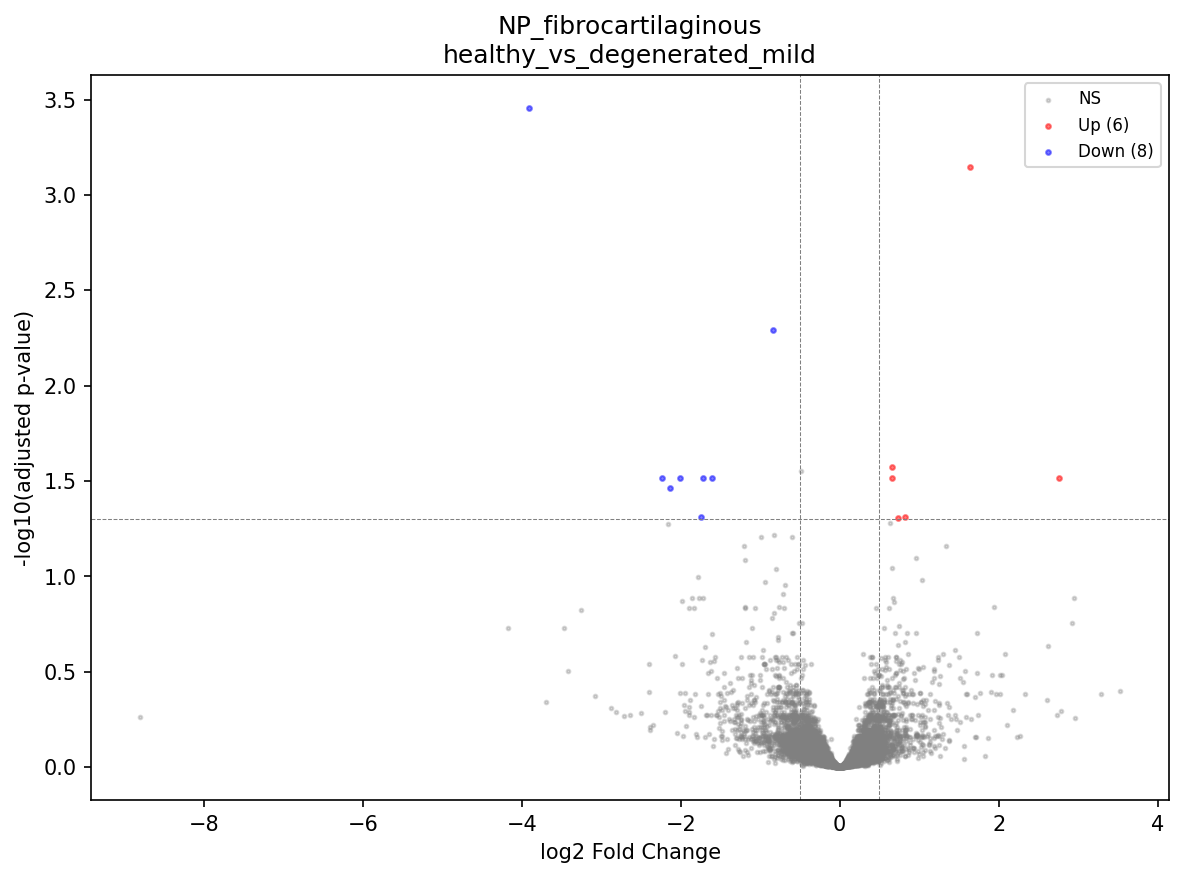

**NP fibrocartilaginous healthy vs degenerated severe**

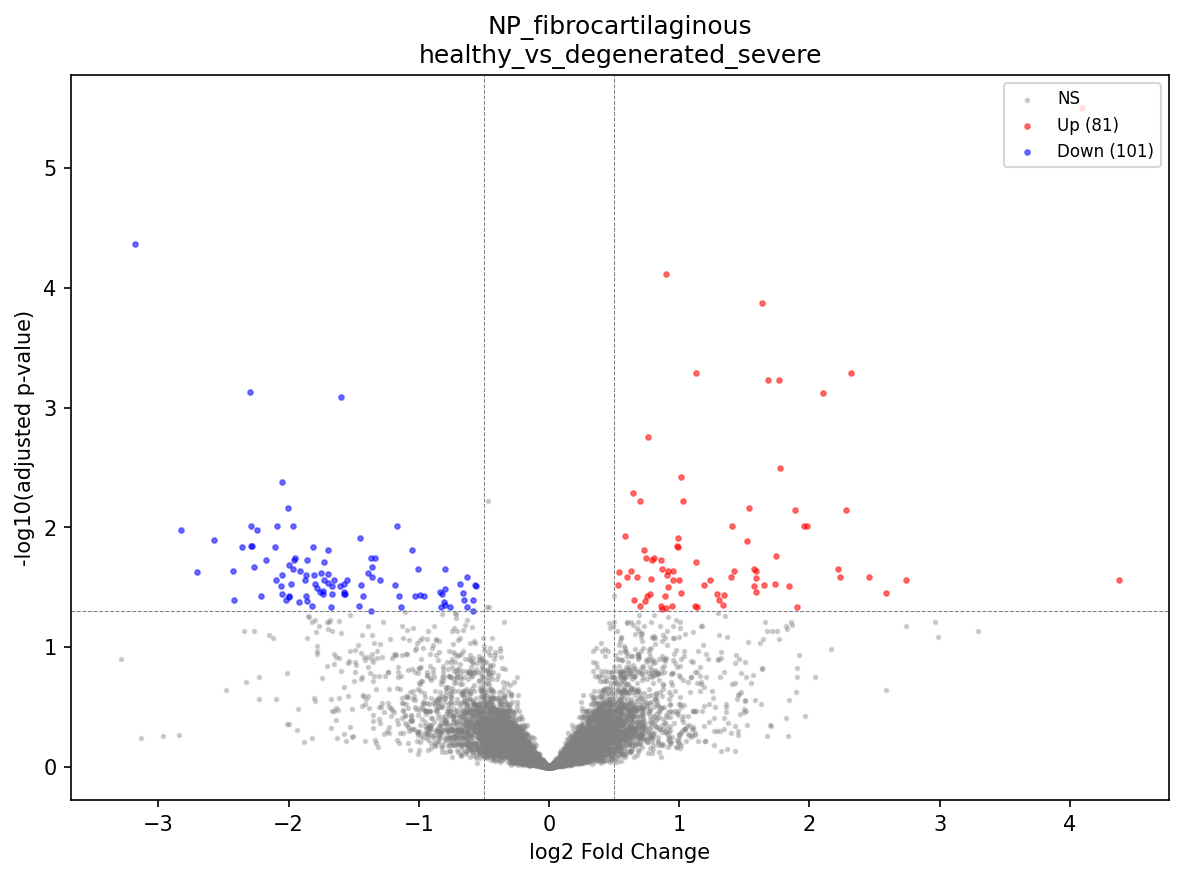

**AF outer healthy vs degenerated all**

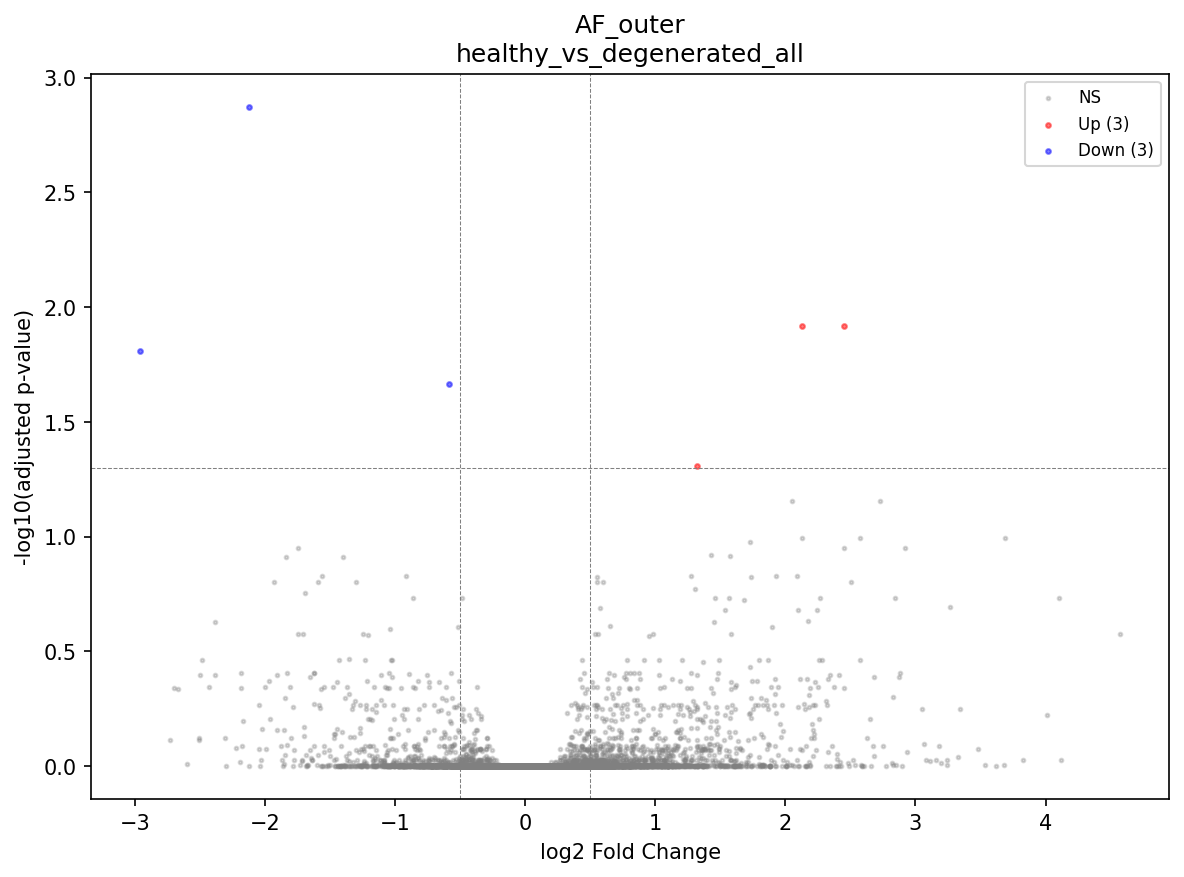

**AF outer healthy vs degenerated mild**

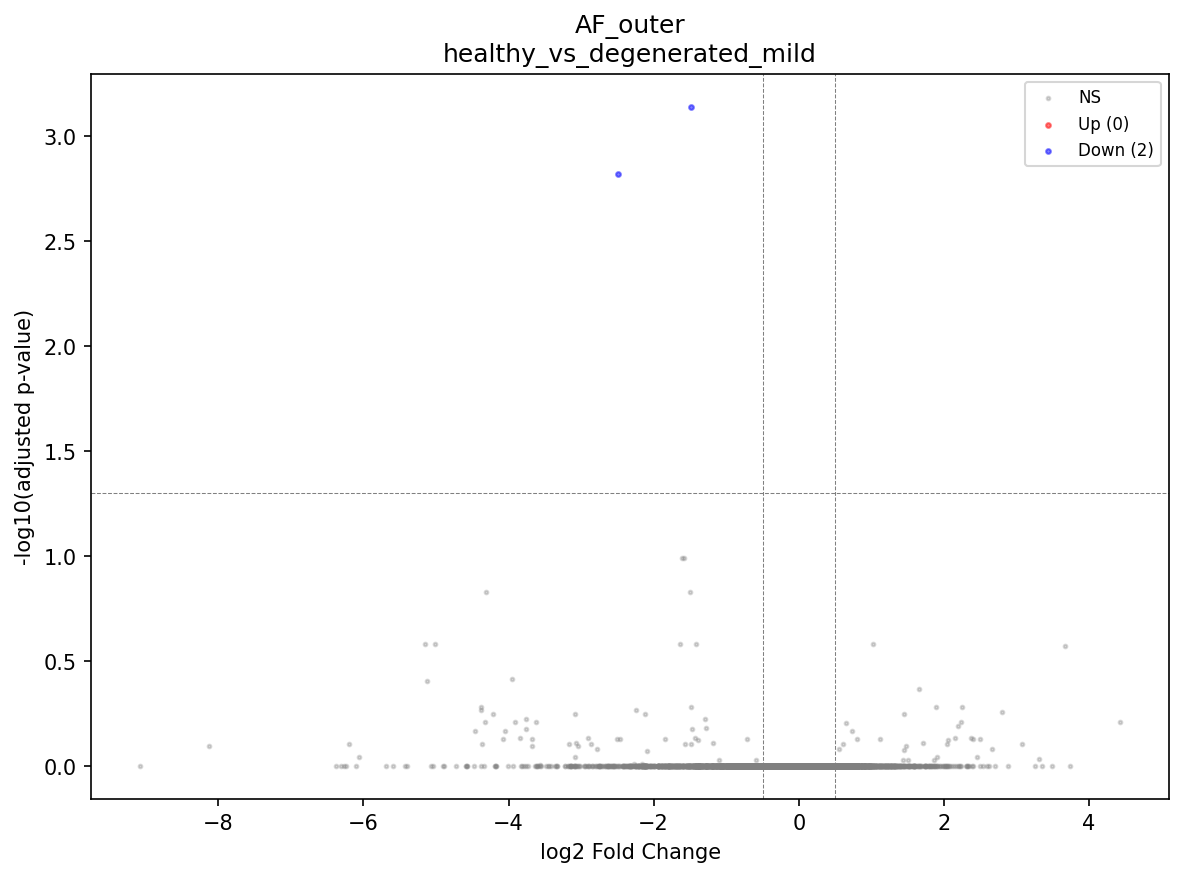

**AF outer healthy vs degenerated severe**

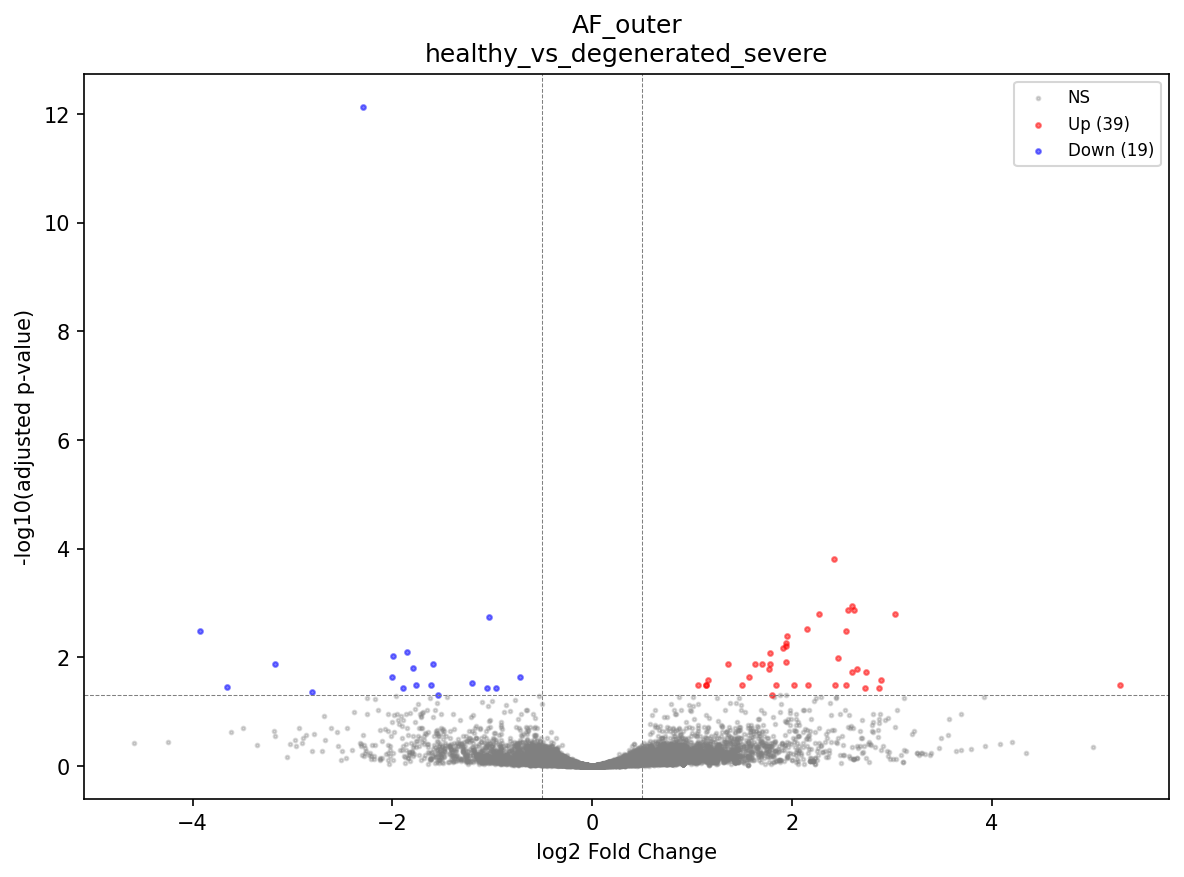

**AF inner healthy vs degenerated all**

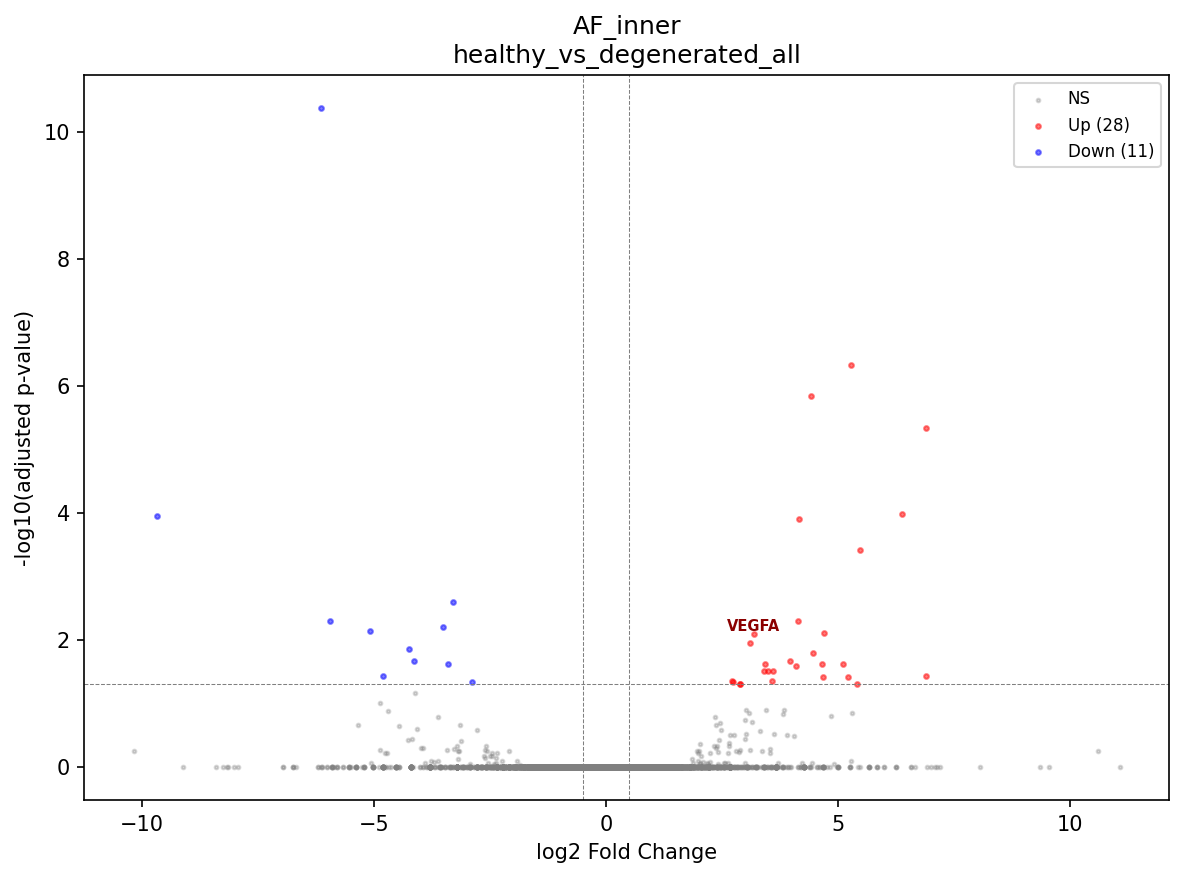

**AF inner healthy vs degenerated severe**

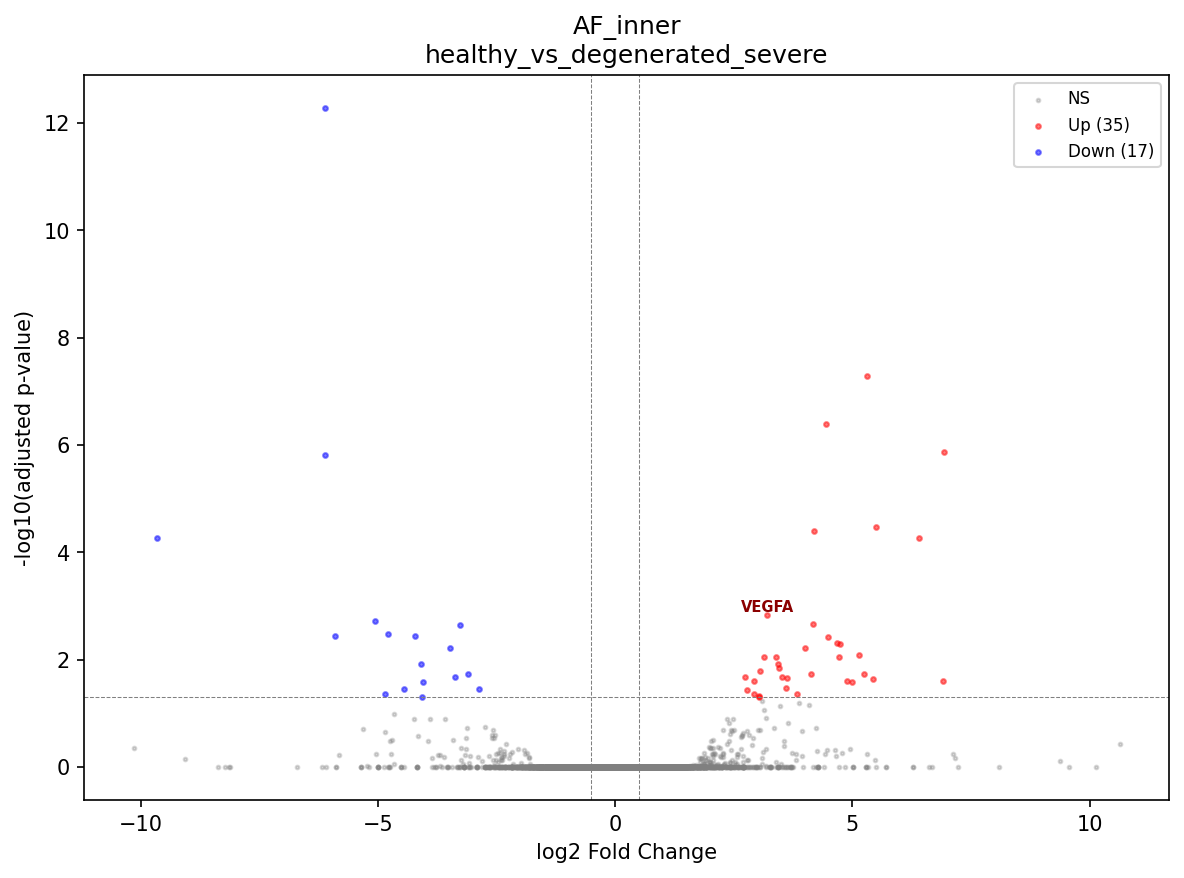

**NP notochordal healthy vs degenerated all**

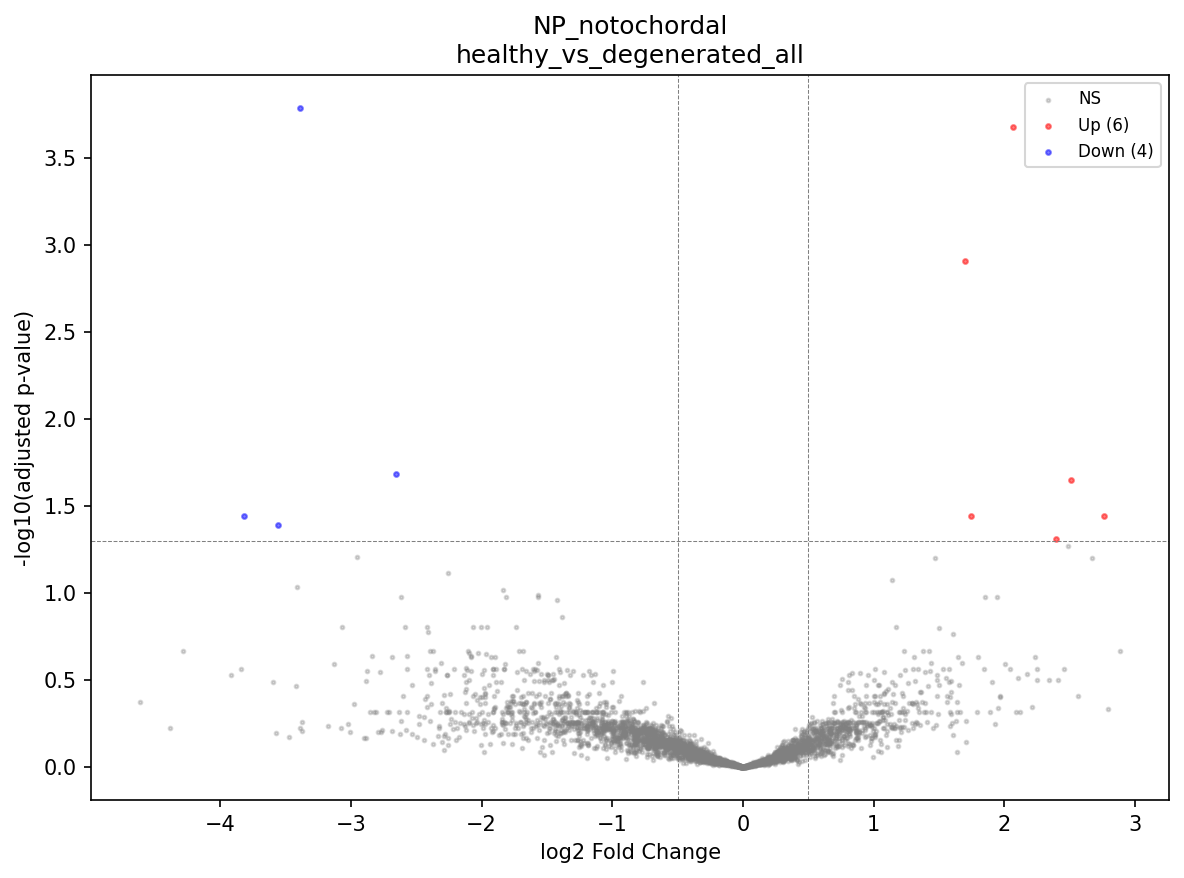

**NP notochordal healthy vs degenerated severe**

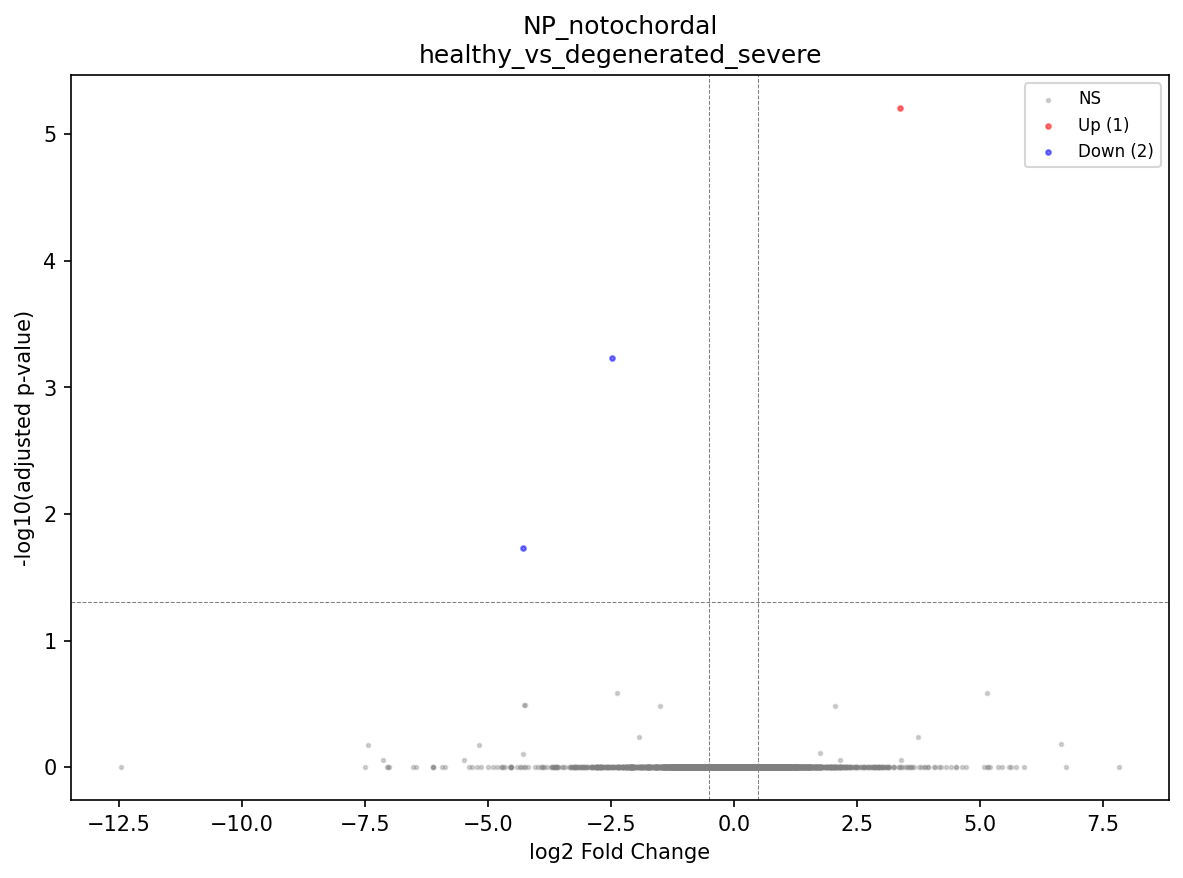

**Fibrochondrocyte chondroid healthy vs degenerated mild**

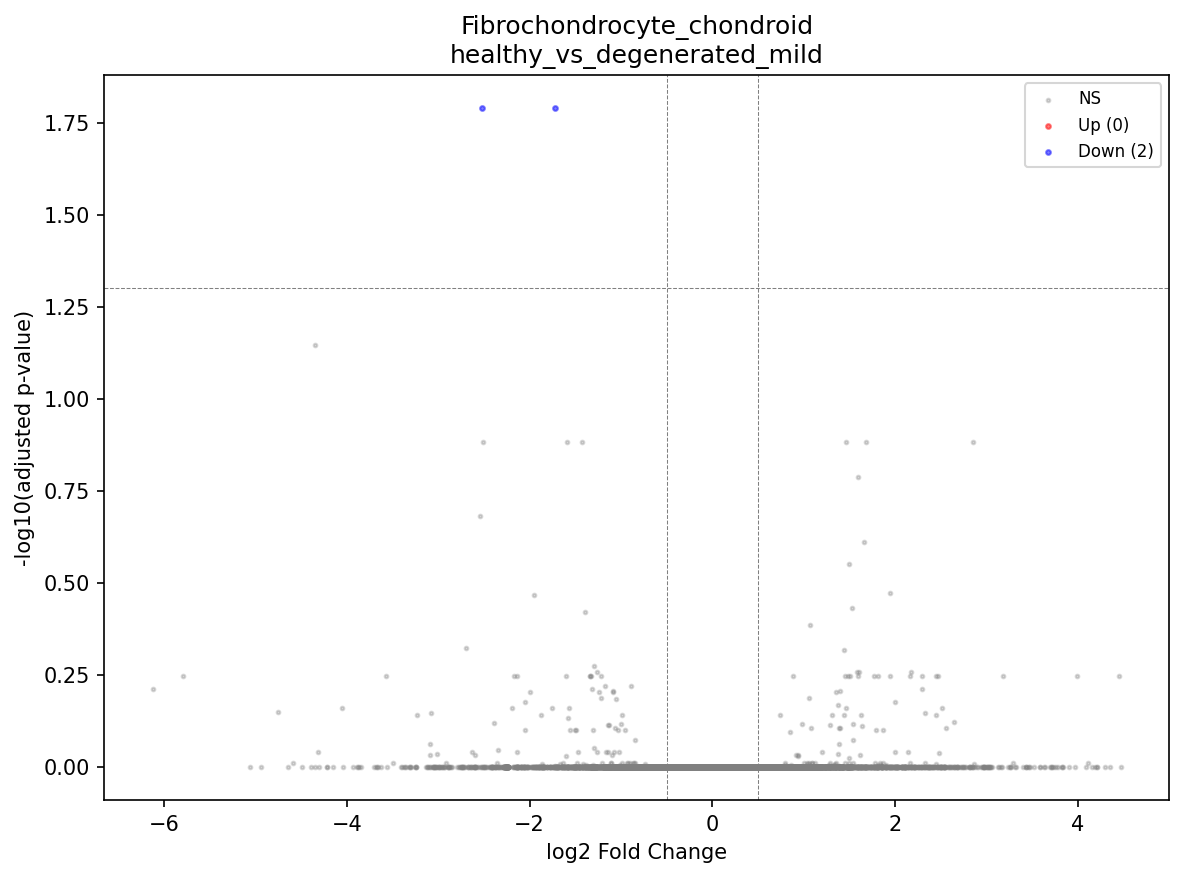

**Fibrochondrocyte chondroid healthy vs degenerated severe**

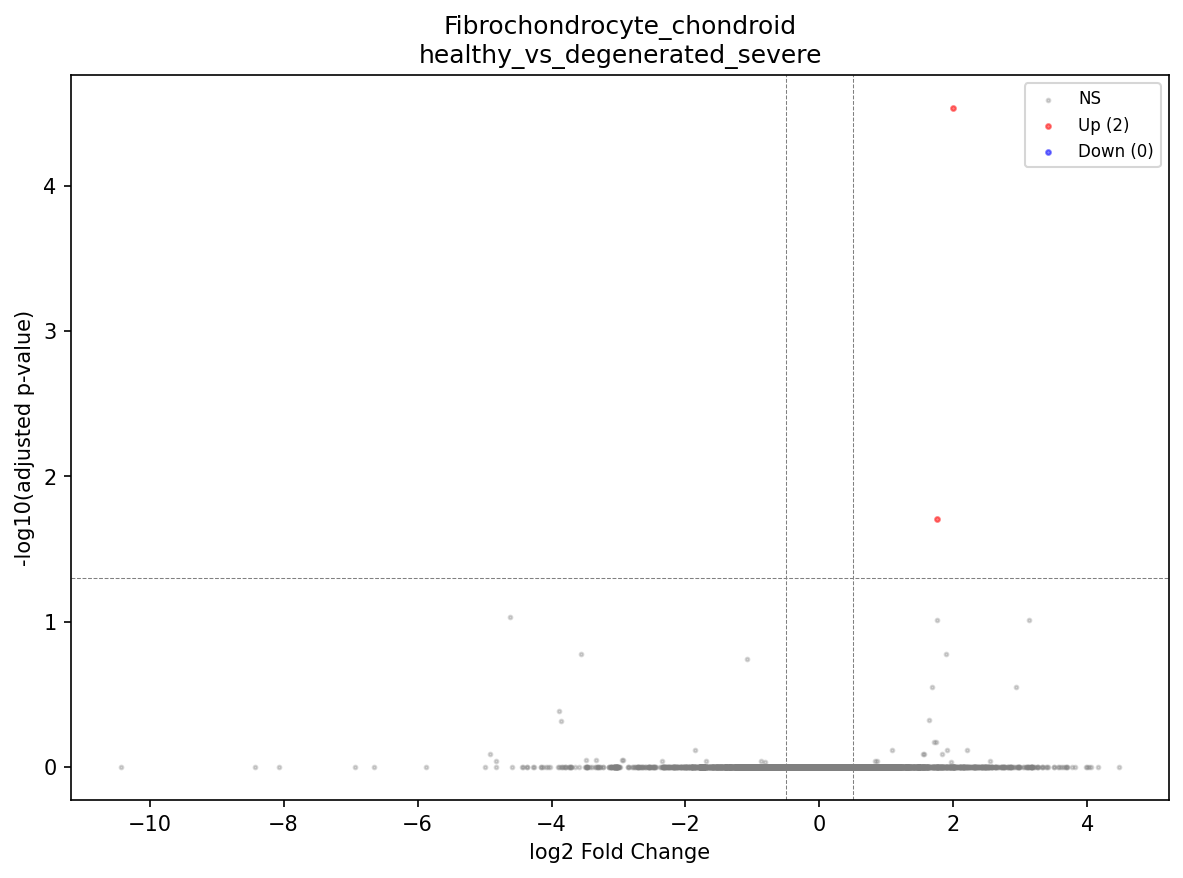

In [5]:
# Display key volcano plots for resident cell types
# Dynamically find available volcano plots rather than hardcoding filenames
key_patterns = [
    'NP_mature_chondrocyte_healthy',
    'NP_fibrocartilaginous_healthy',
    'AF_outer_healthy',
    'AF_inner_healthy',
    'EP_hyaline_healthy',
    'NP_notochordal_healthy',
]

for pattern in key_patterns:
    matches = sorted(VOLCANO_DIR.glob(f'volcano_{pattern}*.png'))
    for fpath in matches:
        label = fpath.stem.replace('volcano_', '').replace('_', ' ')
        display(Markdown(f'**{label}**'))
        display(Image(filename=str(fpath), width=700))

# Show any healthy-vs comparisons not covered above
shown = set()
for pattern in key_patterns:
    shown.update(f.name for f in VOLCANO_DIR.glob(f'volcano_{pattern}*.png'))
remaining_healthy = sorted(f for f in VOLCANO_DIR.glob('*healthy*.png') if f.name not in shown)
for fpath in remaining_healthy:
    label = fpath.stem.replace('volcano_', '').replace('_', ' ')
    display(Markdown(f'**{label}**'))
    display(Image(filename=str(fpath), width=700))

### Severity-stratified comparisons (mild vs severe)

**AF outer mild vs severe**

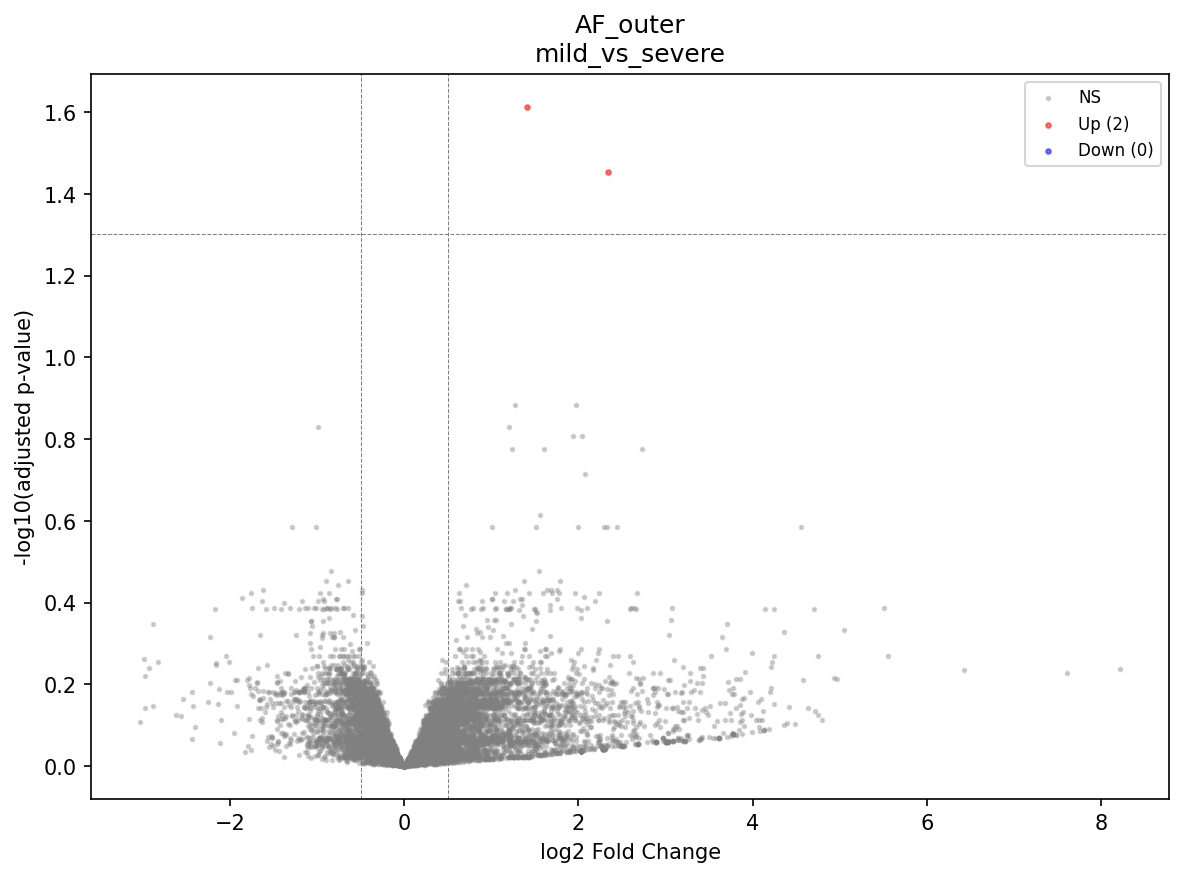

**Fibrochondrocyte chondroid mild vs severe**

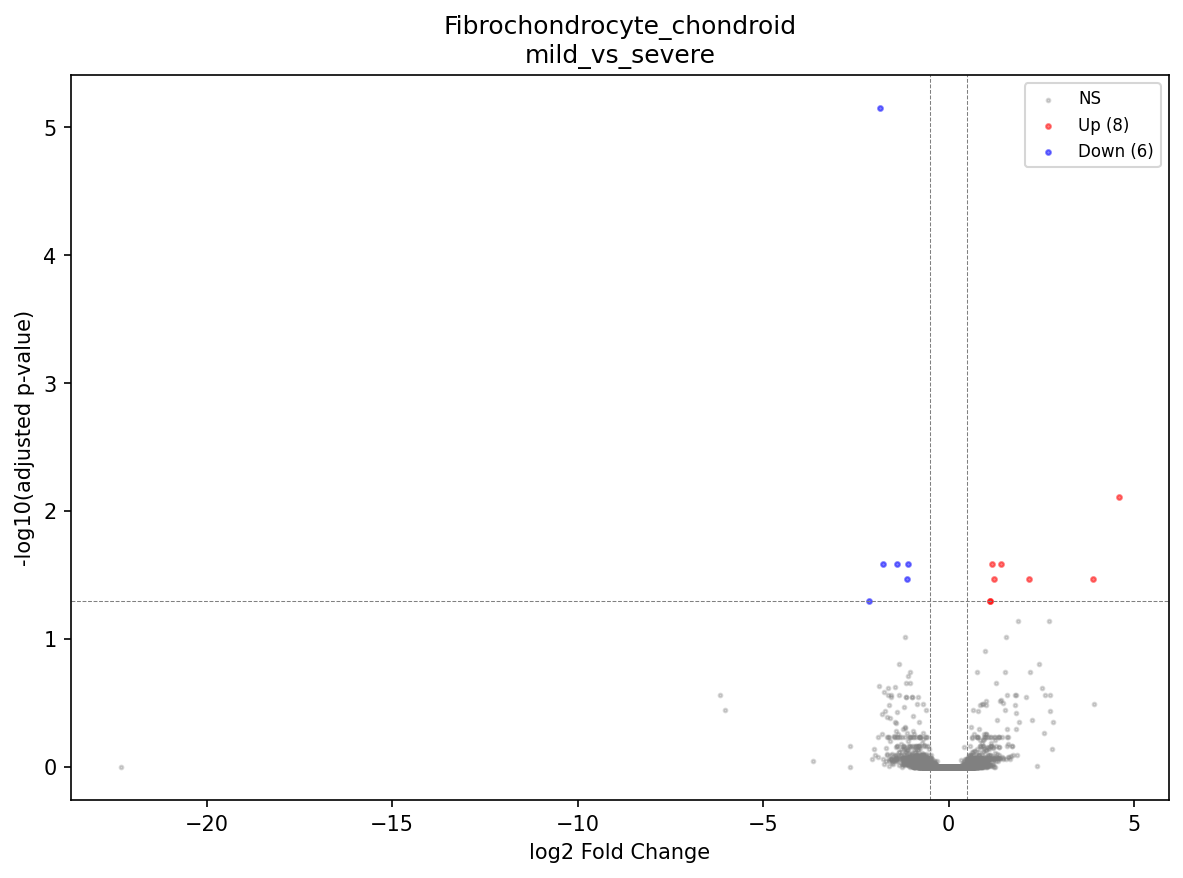

**Fibrochondrocyte stressed mild vs severe**

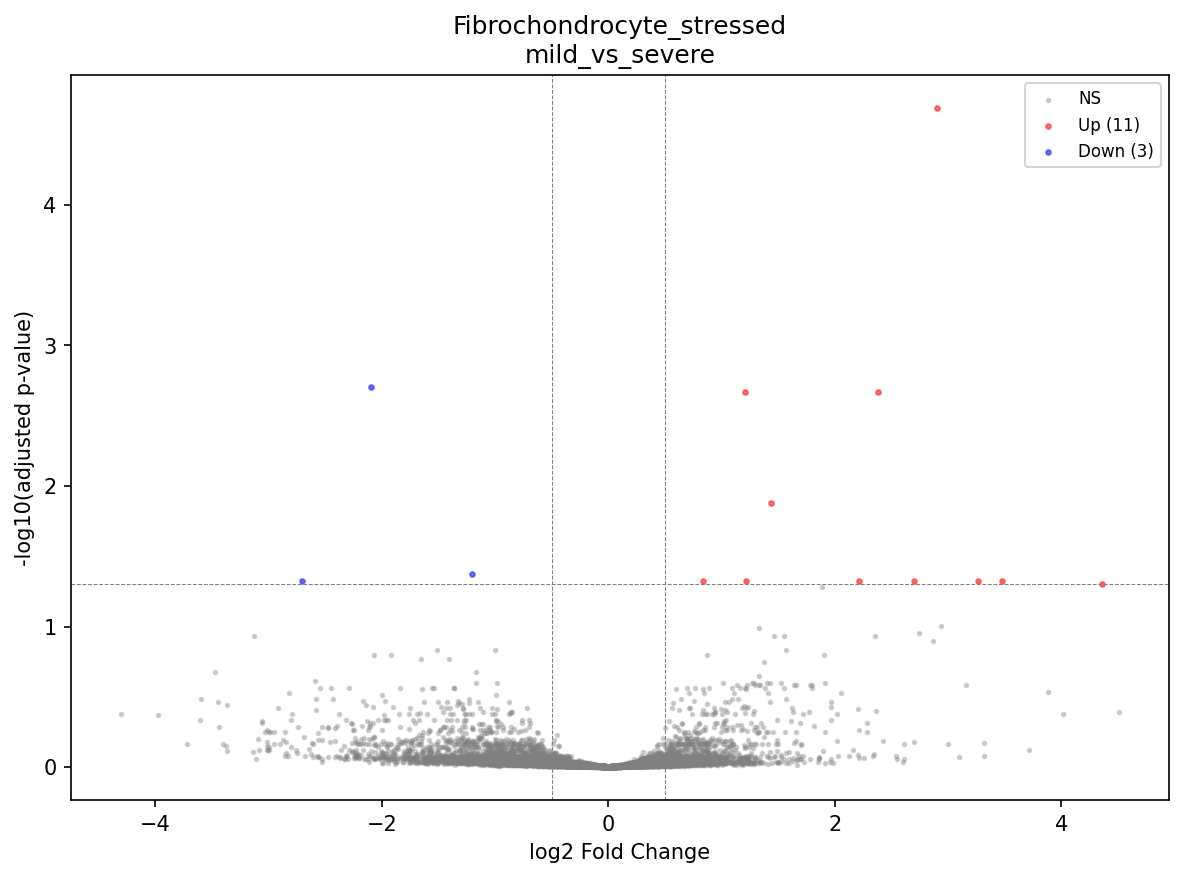

**NP fibrocartilaginous mild vs severe**

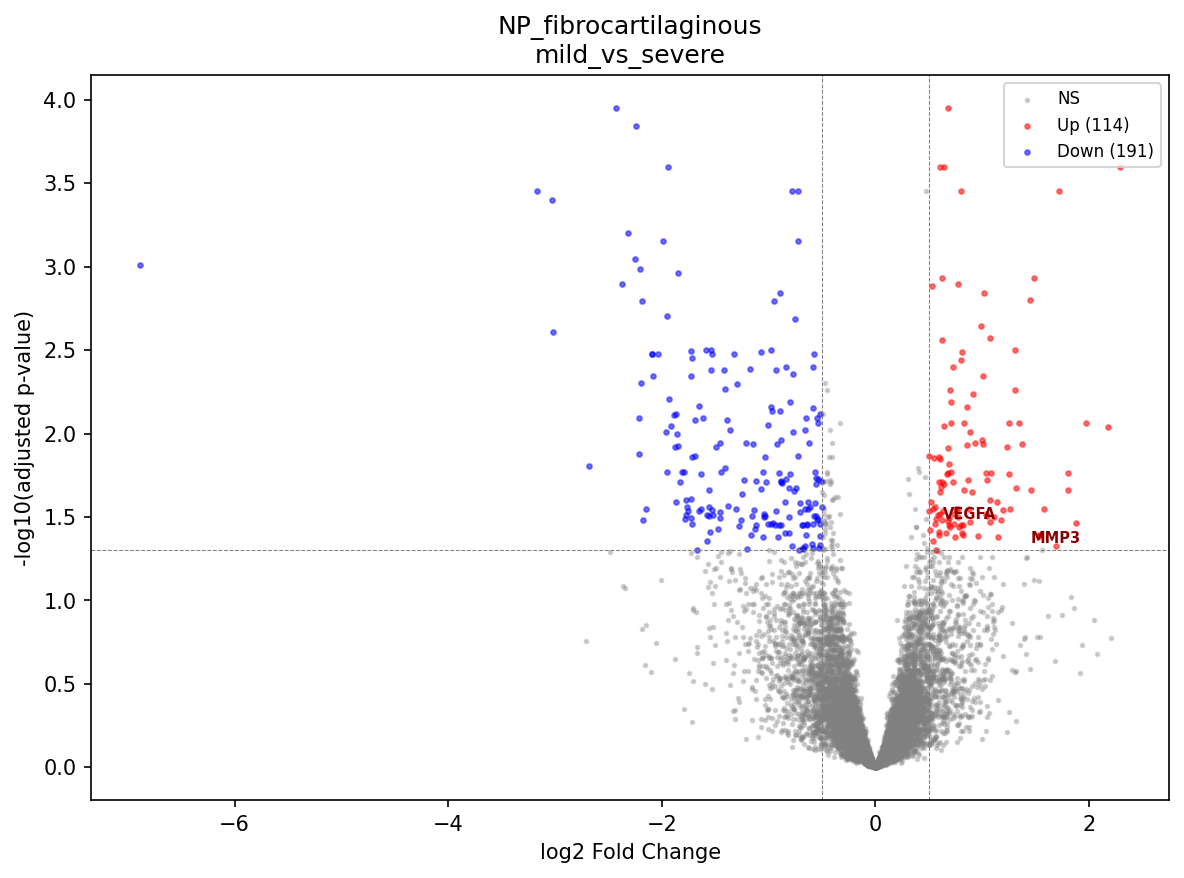

**NP mature chondrocyte mild vs severe**

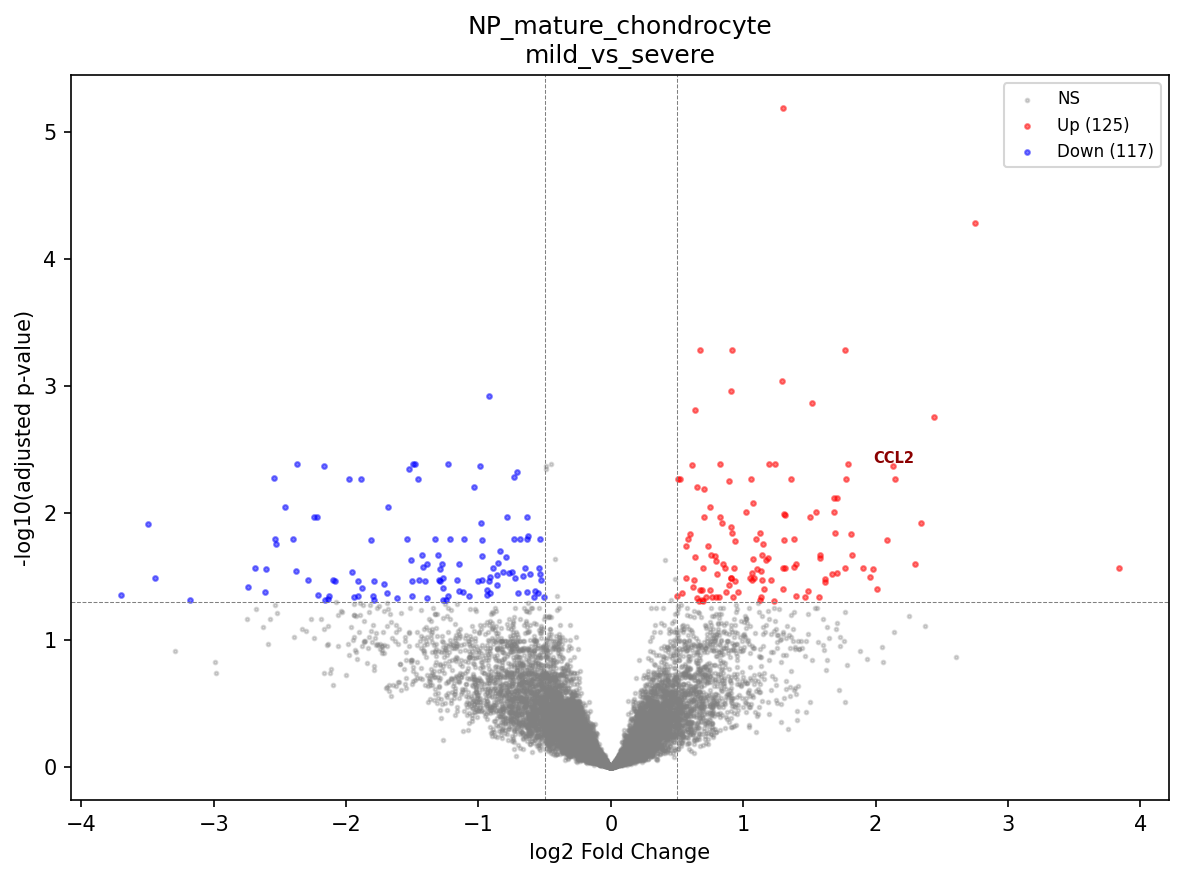

**NP notochordal mild vs severe**

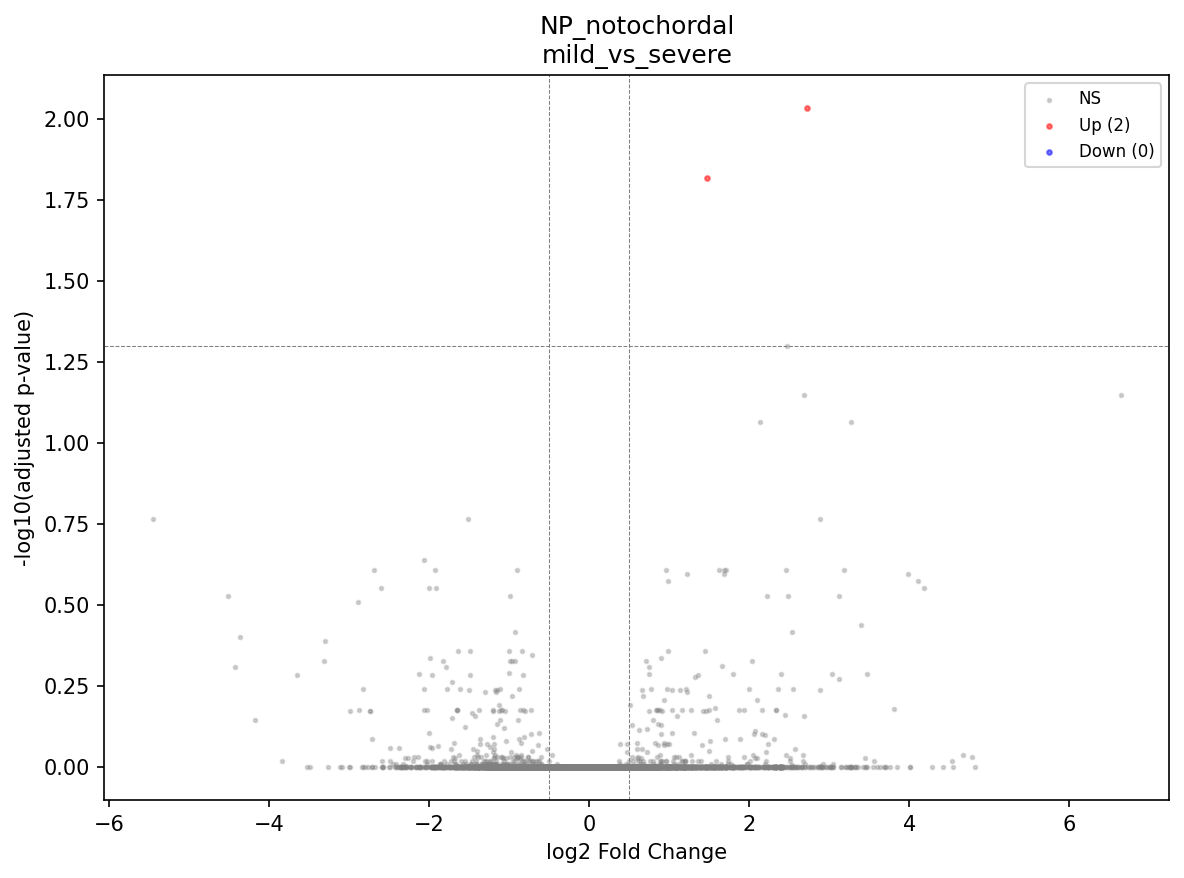

**NP stressed degen mild vs severe**

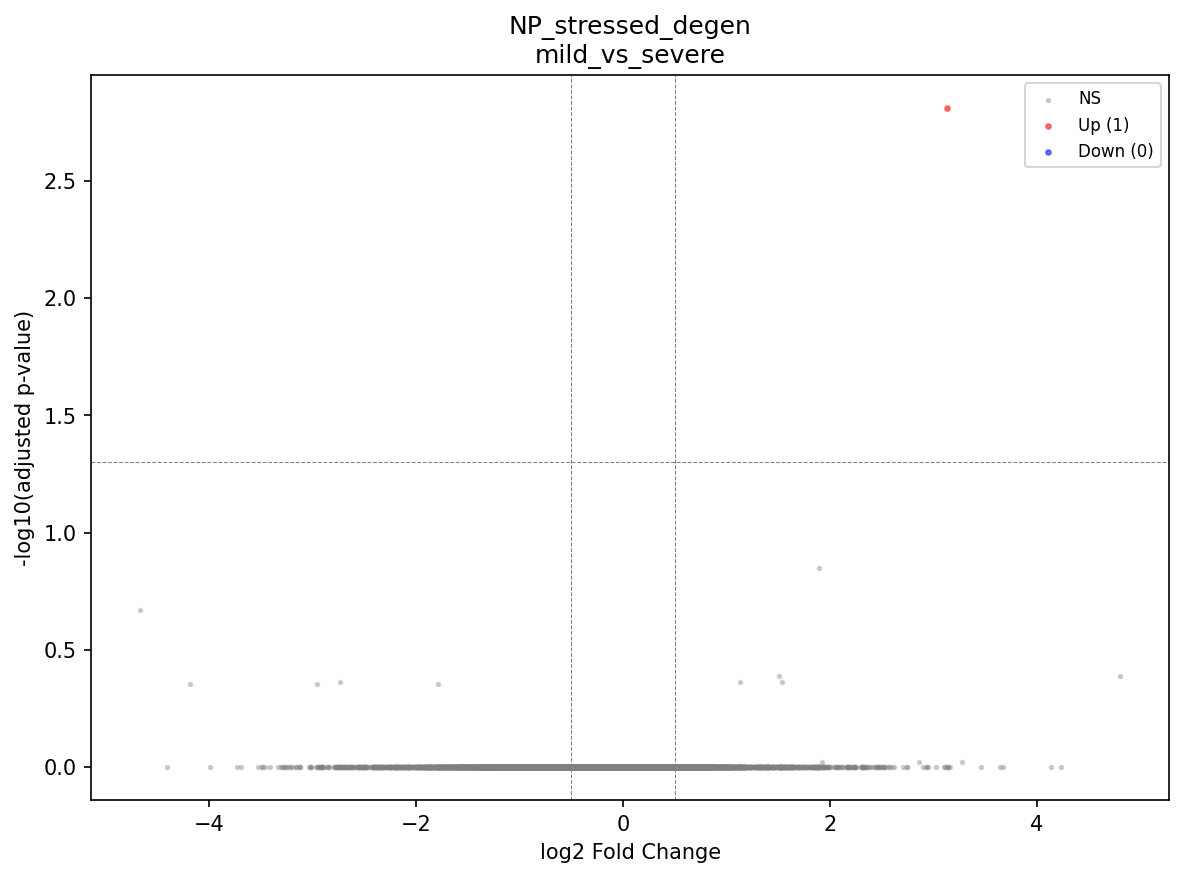

**T cell mild vs severe**

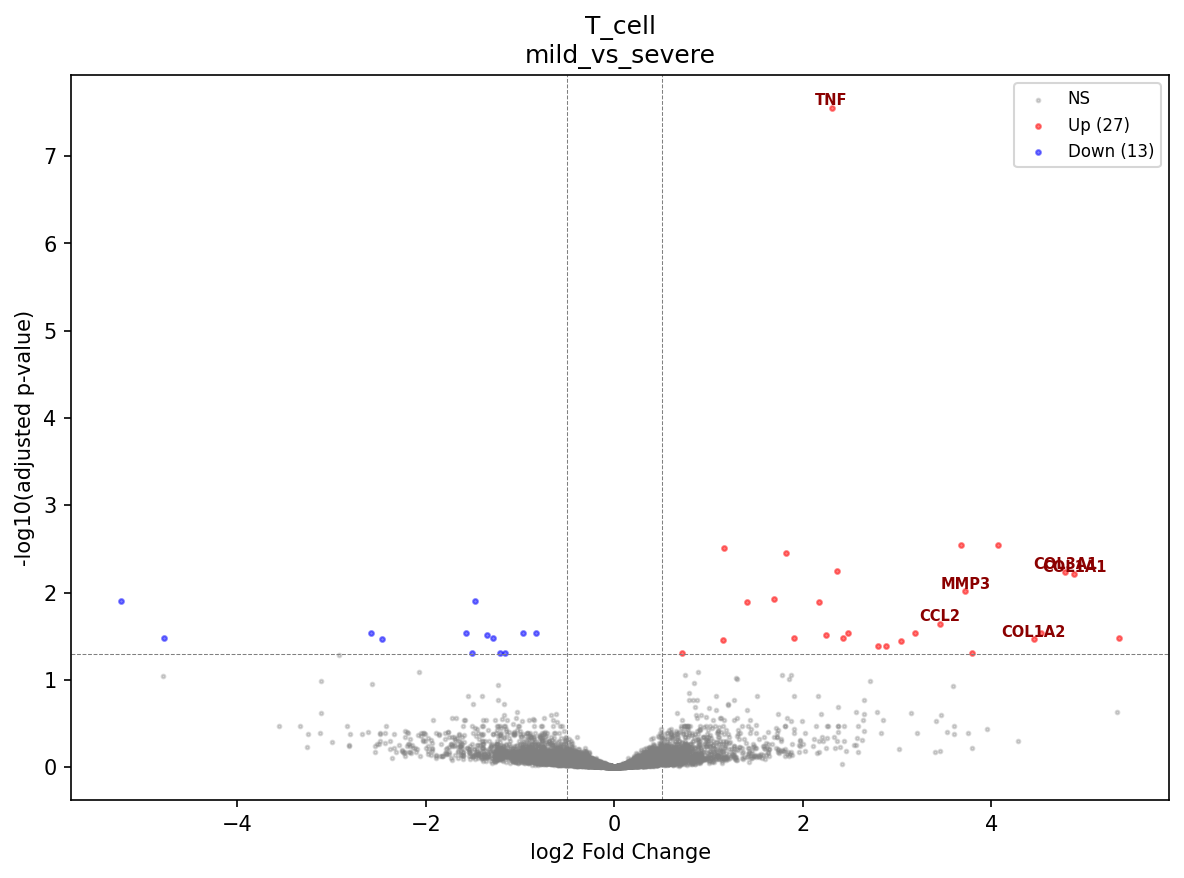

**unassigned mild vs severe**

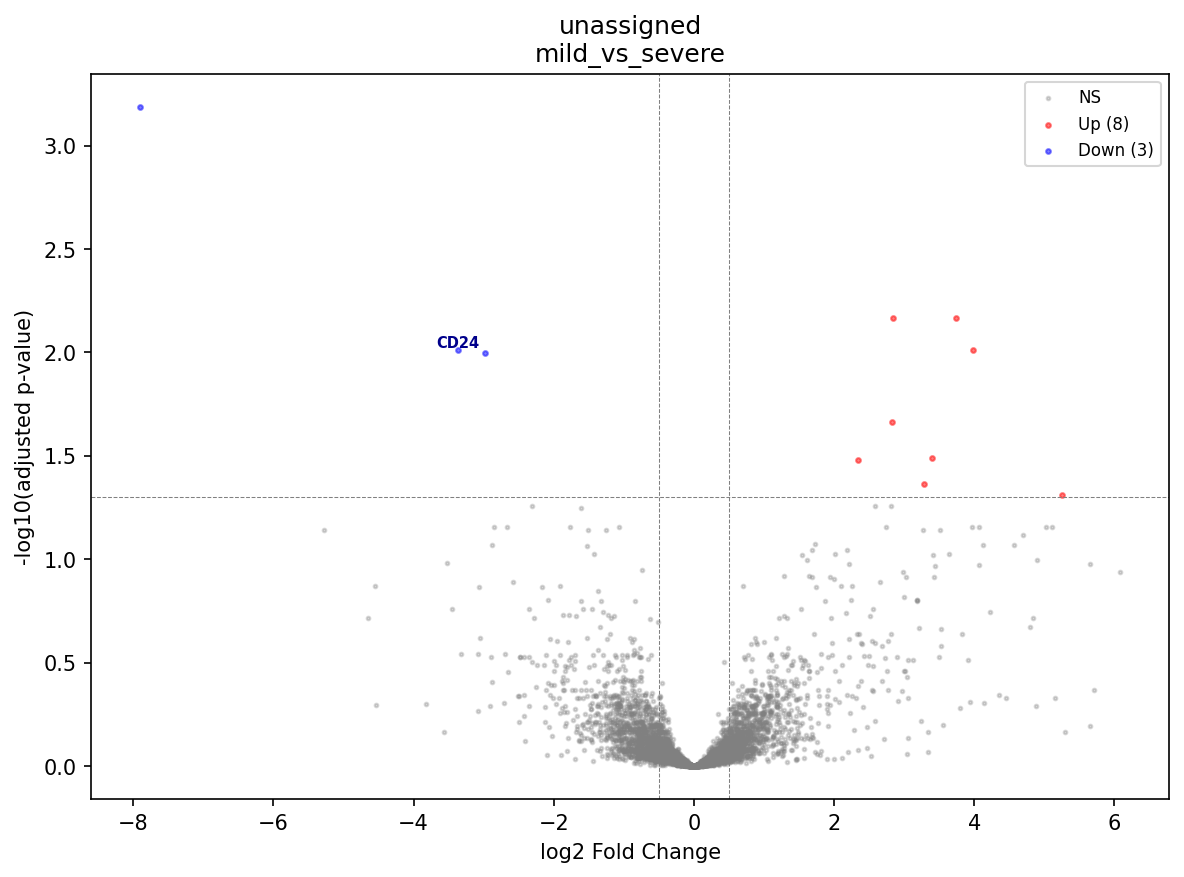

In [6]:
# Display mild vs severe comparisons
severity_volcanos = sorted(VOLCANO_DIR.glob('*mild_vs_severe*.png'))

for fpath in severity_volcanos:
    label = fpath.stem.replace('volcano_', '').replace('_', ' ')
    display(Markdown(f'**{label}**'))
    display(Image(filename=str(fpath), width=700))

### All remaining volcano plots

Remaining volcano plots: 2


**Fibrochondrocyte chondroid healthy vs degenerated mild**

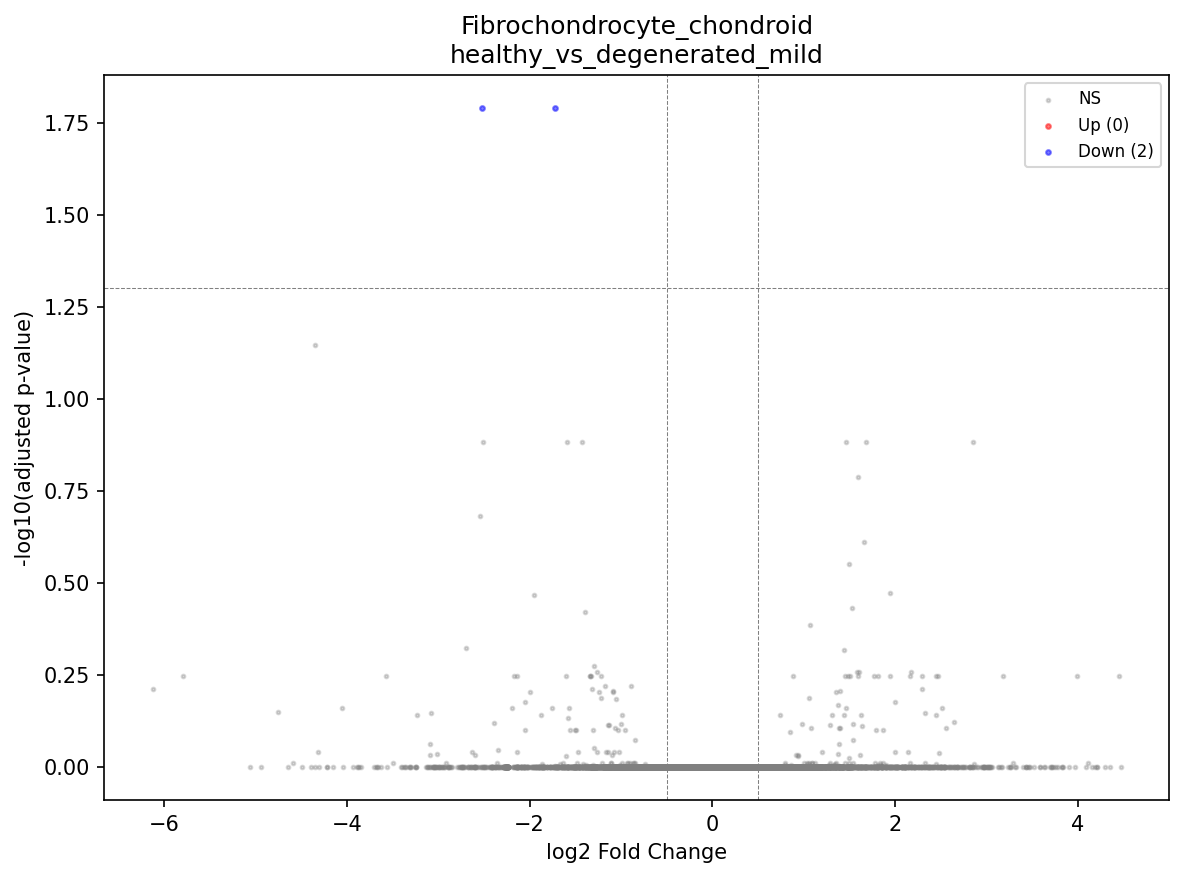

**Fibrochondrocyte chondroid healthy vs degenerated severe**

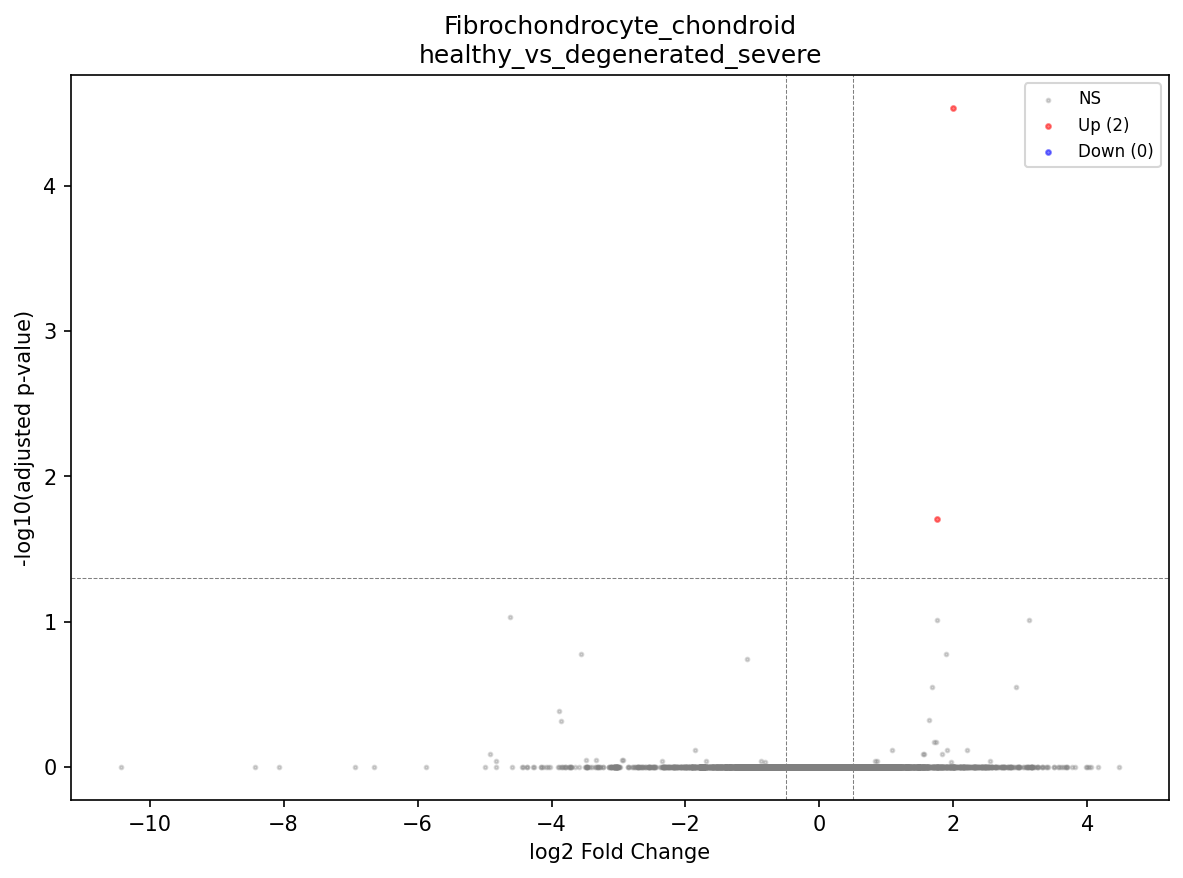

In [7]:
# Show any remaining volcano plots not already displayed
already_shown_patterns = [
    'NP_mature_chondrocyte_healthy',
    'NP_fibrocartilaginous_healthy',
    'AF_outer_healthy',
    'AF_inner_healthy',
    'EP_hyaline_healthy',
    'NP_notochordal_healthy',
]
already_shown = set()
for pattern in already_shown_patterns:
    already_shown.update(f.name for f in VOLCANO_DIR.glob(f'volcano_{pattern}*.png'))
already_shown.update(f.name for f in VOLCANO_DIR.glob('*mild_vs_severe*.png'))

remaining = sorted(f for f in VOLCANO_DIR.glob('*.png') if f.name not in already_shown)

print(f'Remaining volcano plots: {len(remaining)}')
for fpath in remaining:
    label = fpath.stem.replace('volcano_', '').replace('_', ' ')
    display(Markdown(f'**{label}**'))
    display(Image(filename=str(fpath), width=700))

## Heatmaps — Top DE Genes

Heatmaps show expression of the top differentially expressed genes across
pseudobulk samples (donors), organized by condition. These complement the
volcano plots by showing the consistency of expression changes across donors.

Heatmap files: 4


**AF inner healthy vs deg**

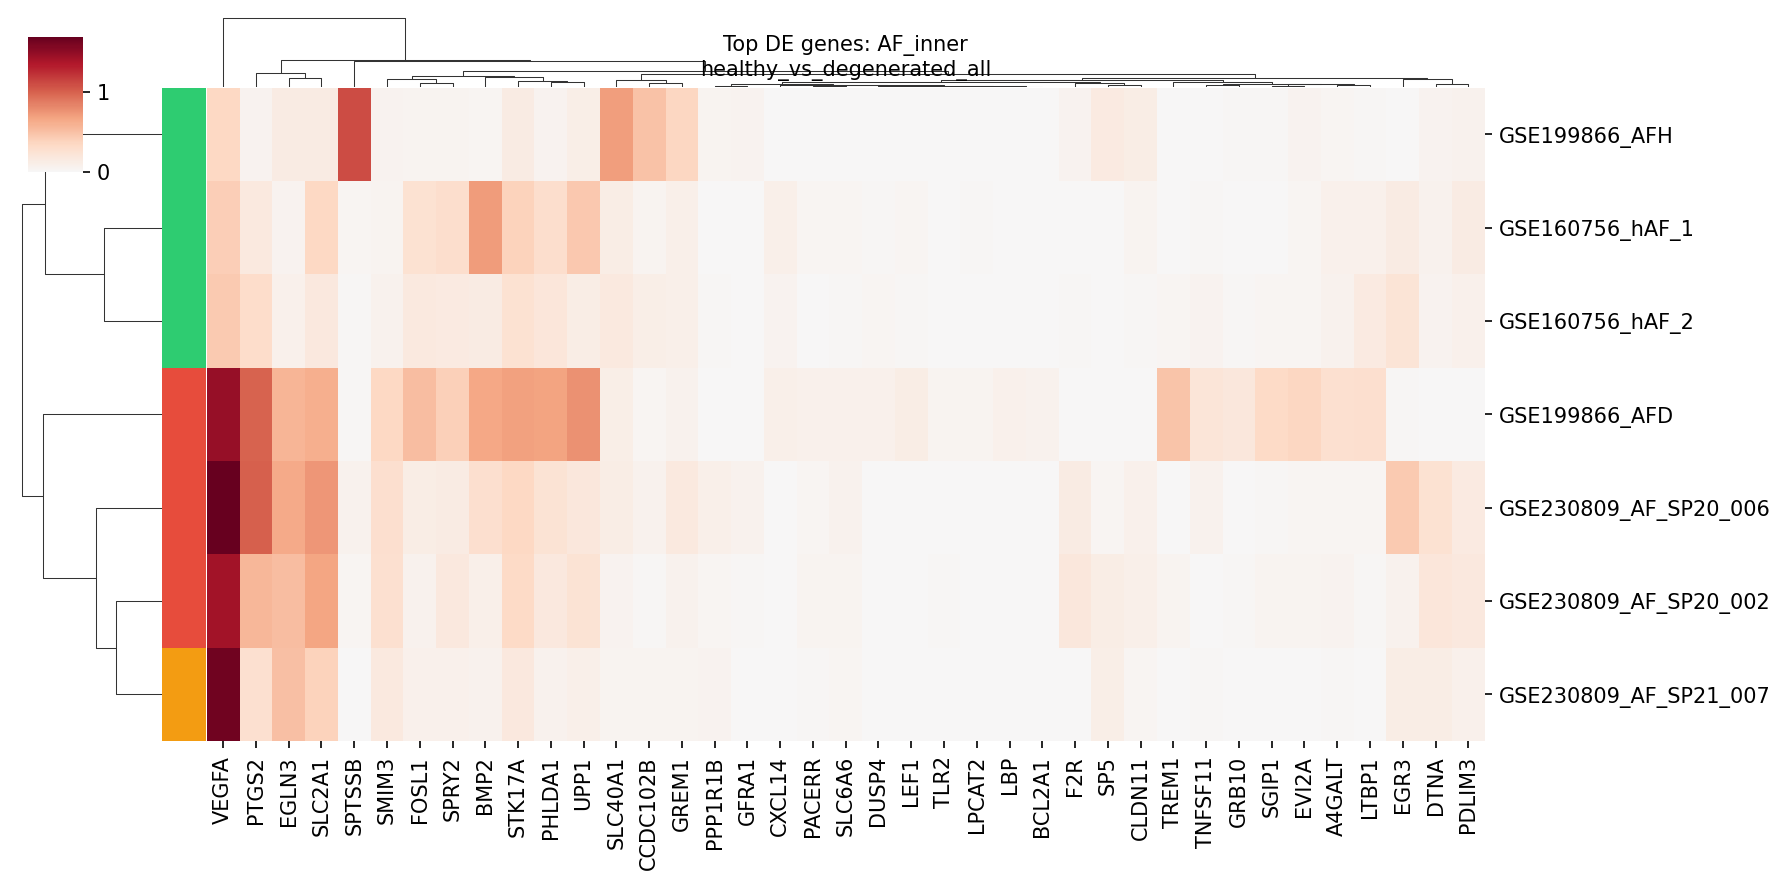

**AF outer healthy vs deg**

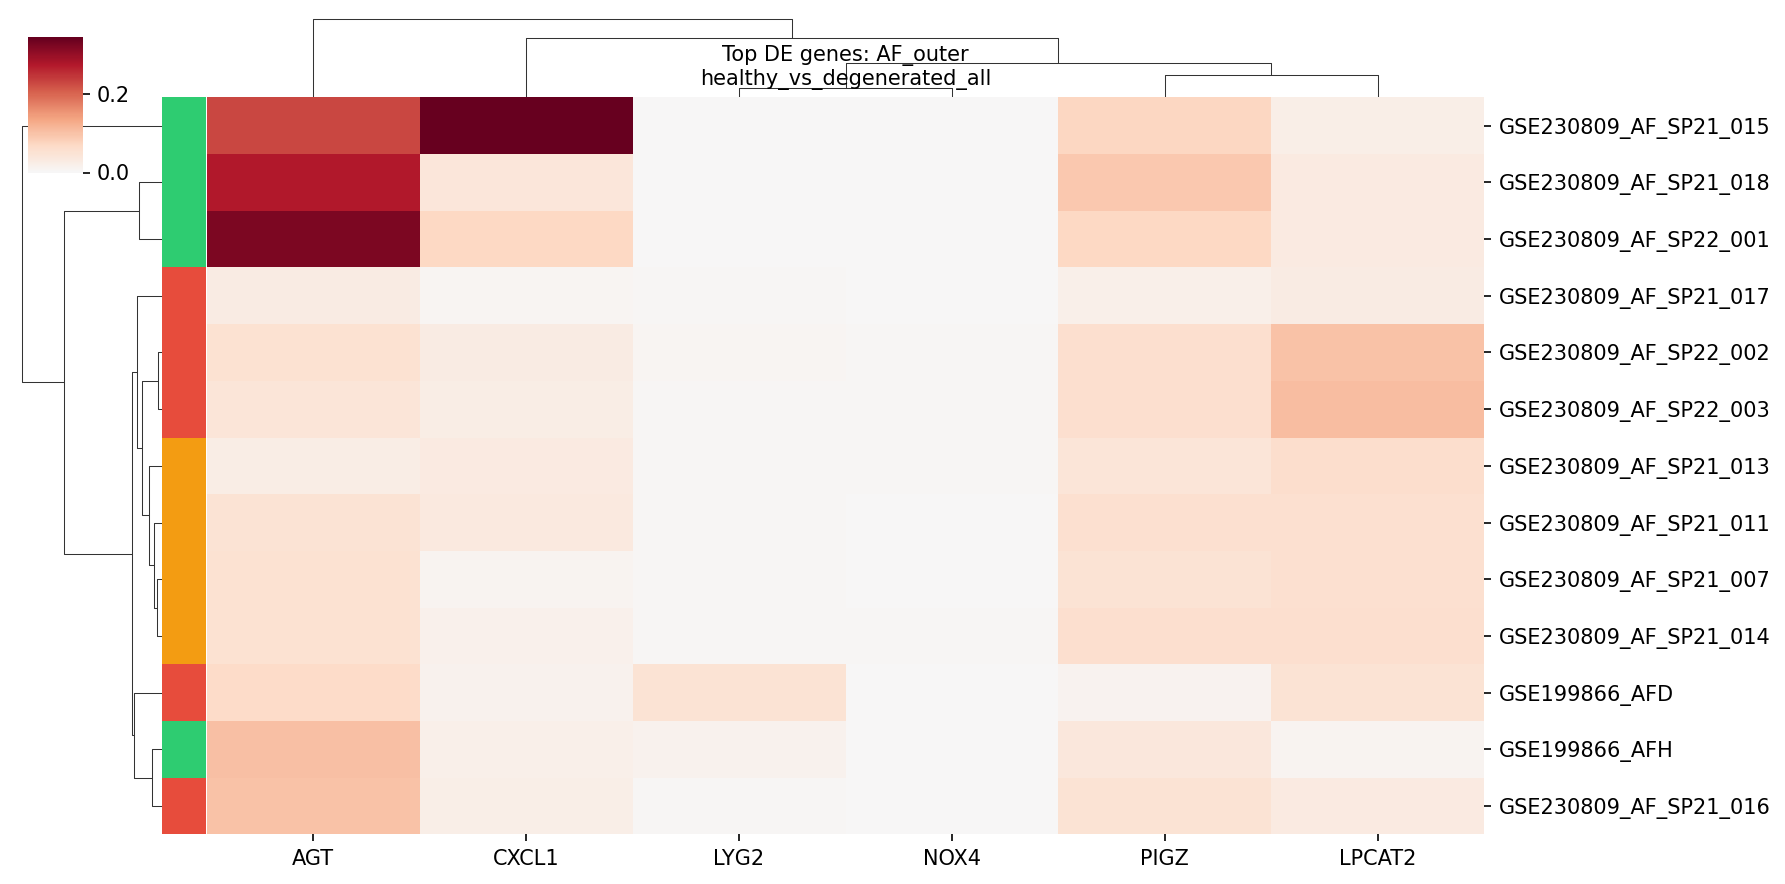

**NP fibrocartilaginous healthy vs deg**

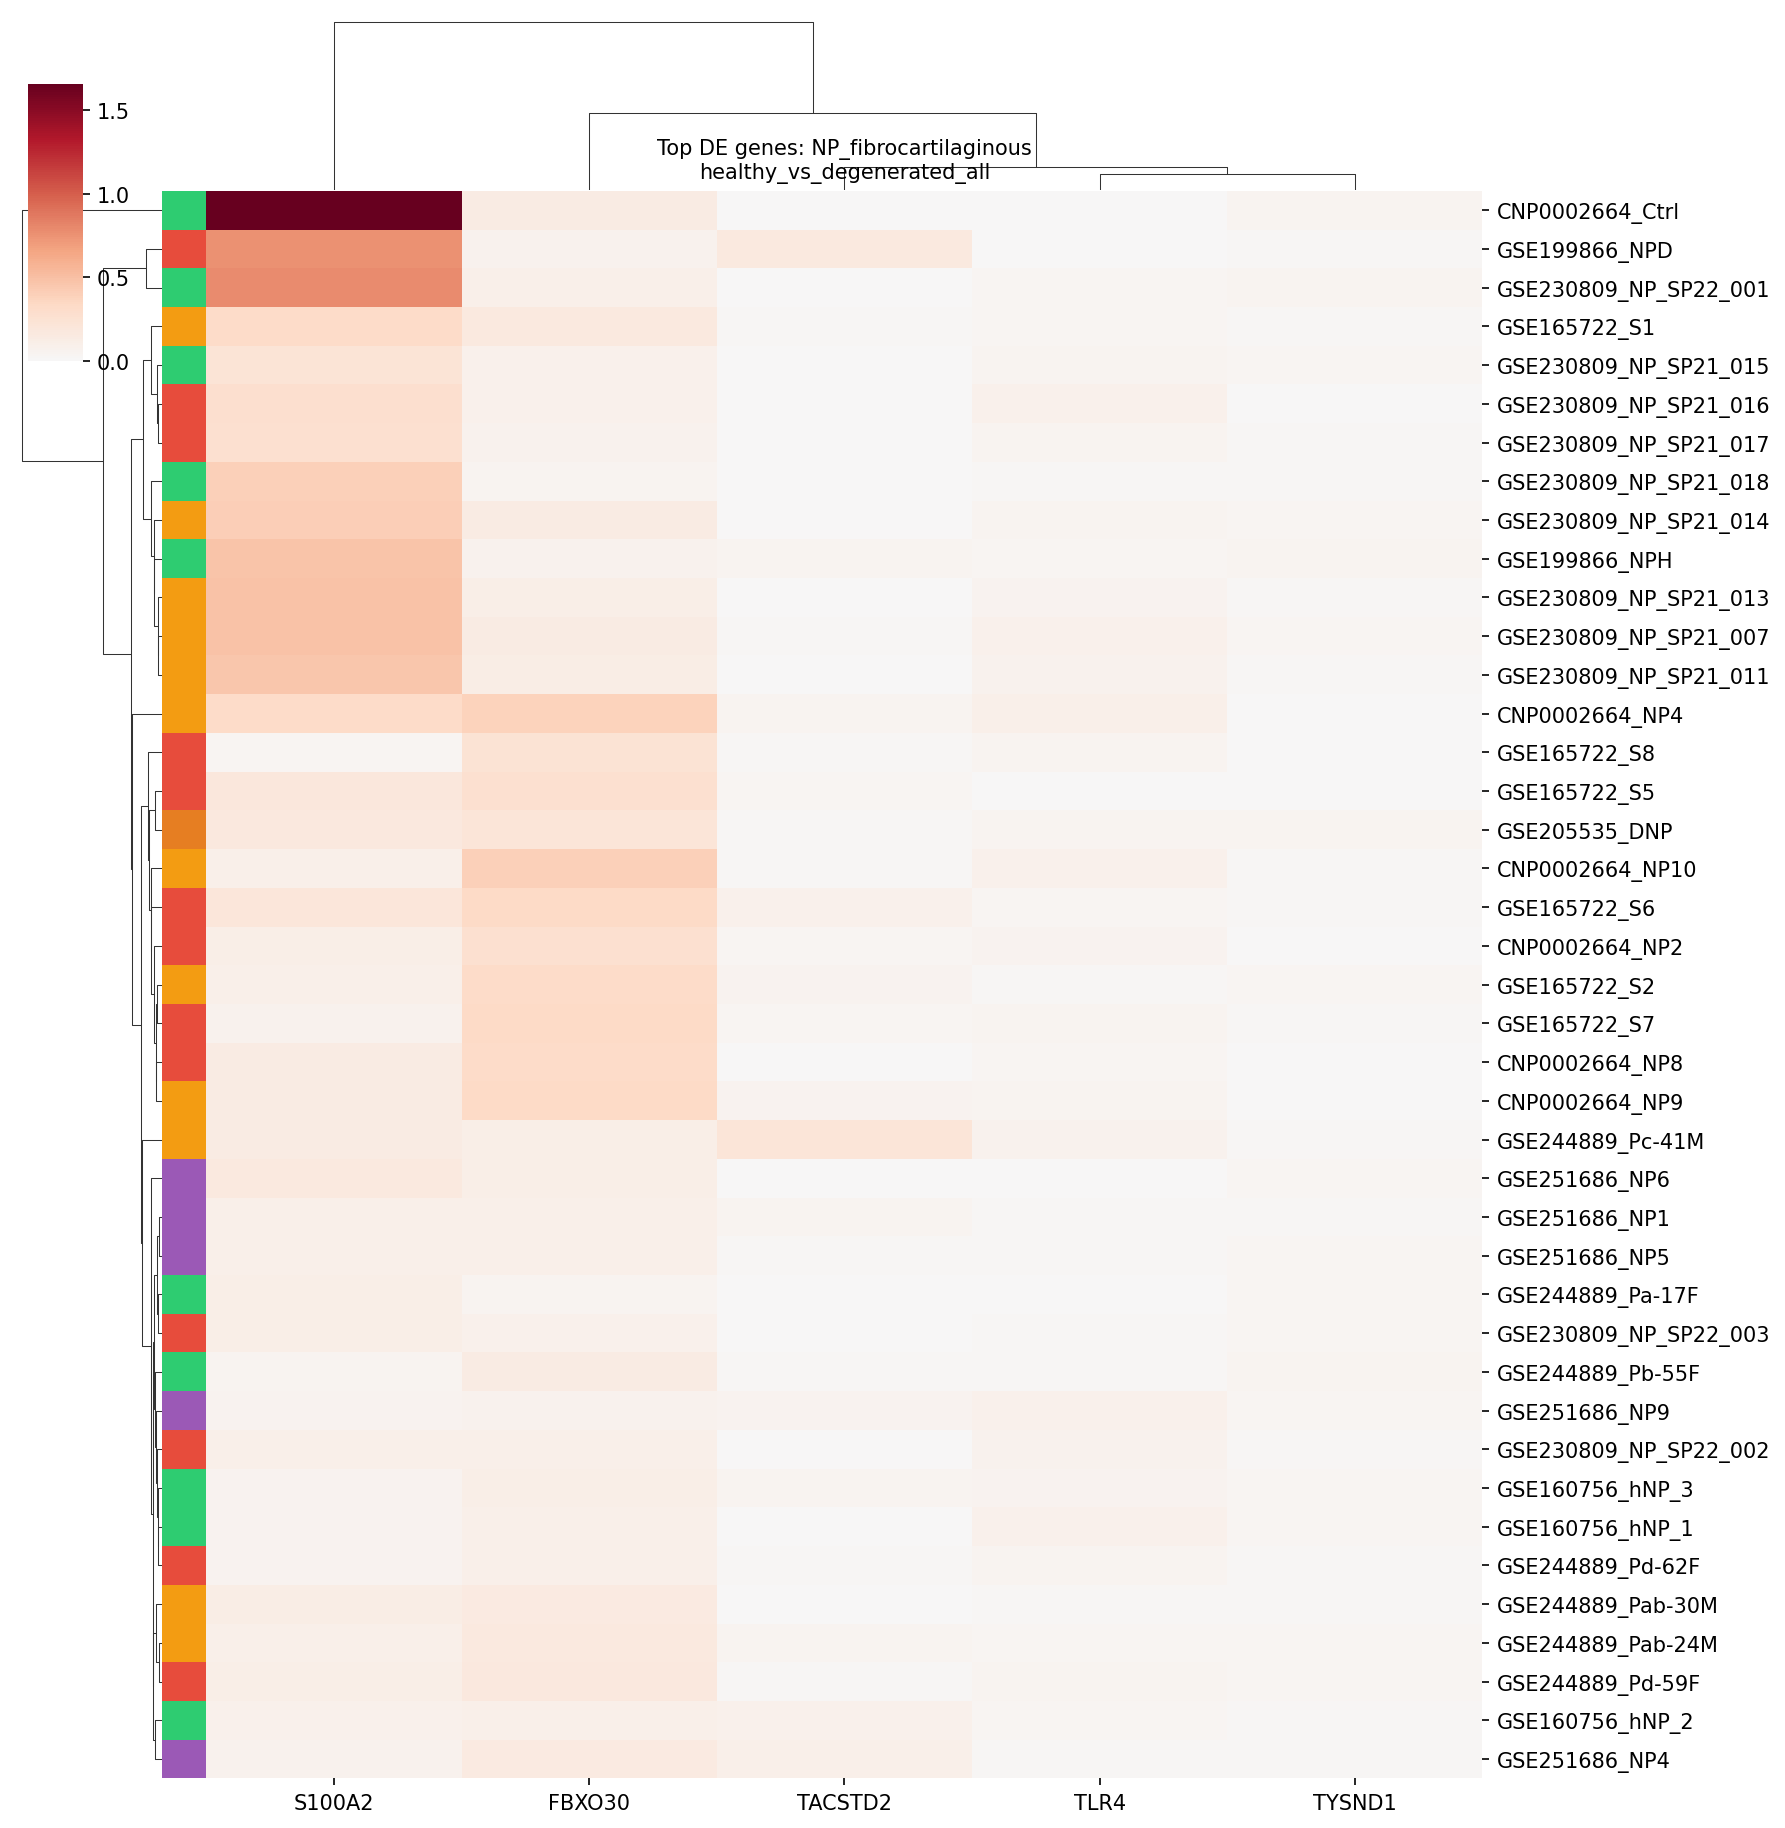

**NP notochordal healthy vs deg**

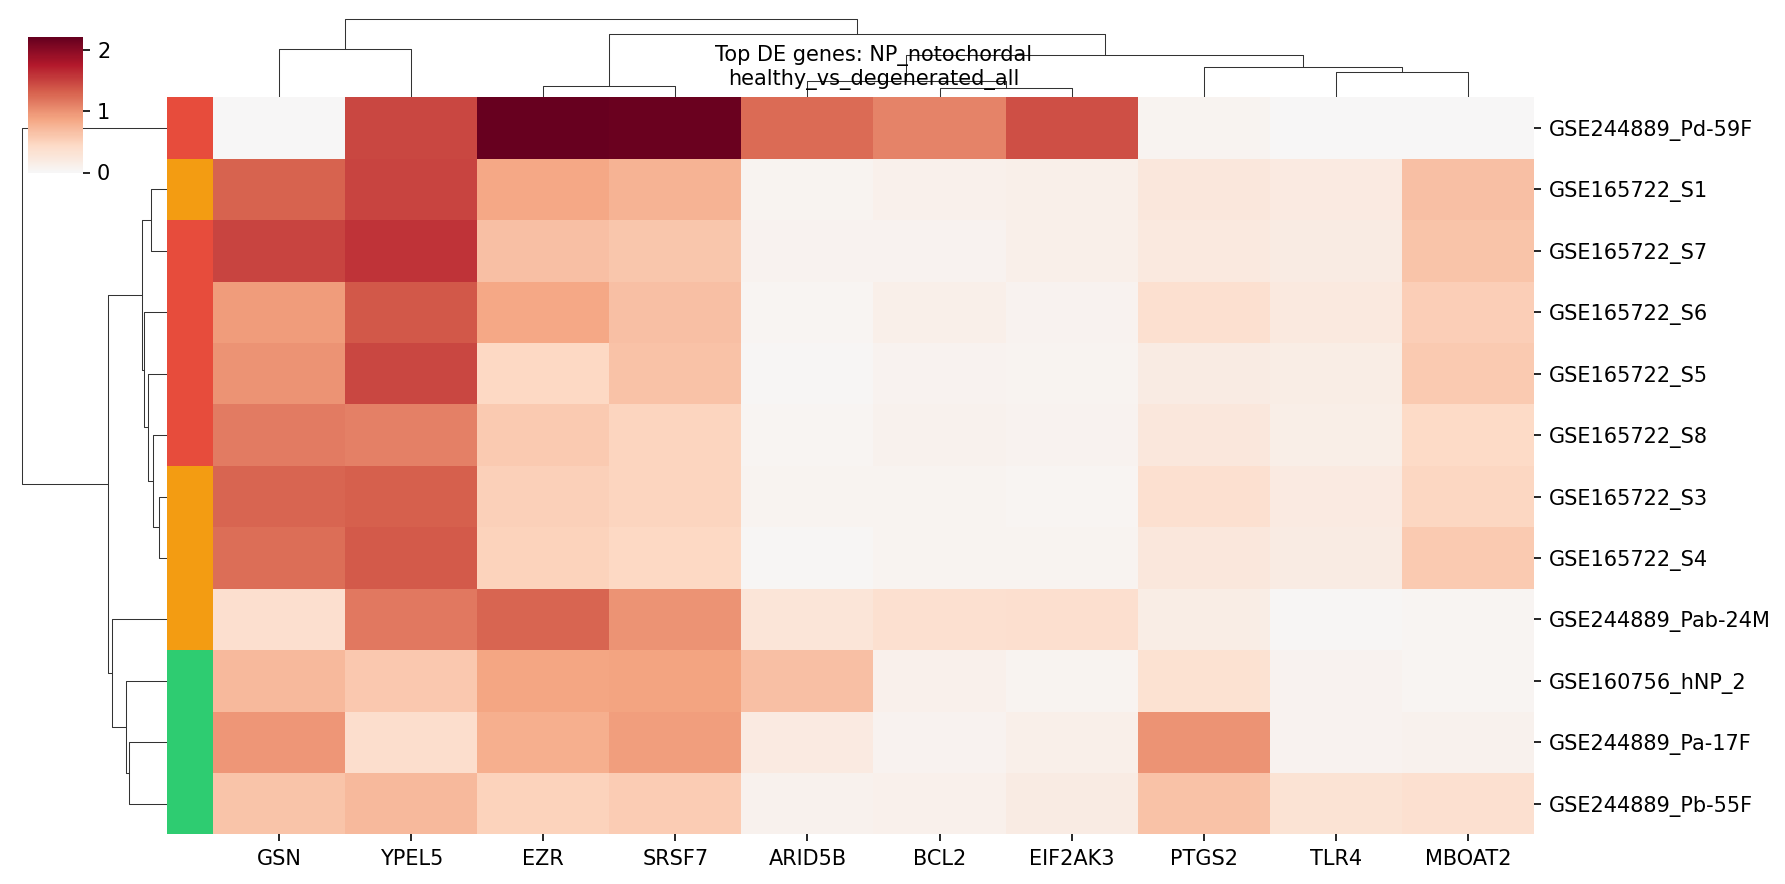

In [8]:
heatmap_files = sorted(HEATMAP_DIR.glob('*.png'))
print(f'Heatmap files: {len(heatmap_files)}')

for fpath in heatmap_files:
    label = fpath.stem.replace('heatmap_', '').replace('_', ' ')
    display(Markdown(f'**{label}**'))
    display(Image(filename=str(fpath), width=800))

## Composition Analysis

Cell type proportion changes between conditions, tested with permutation-based
methods.

In [9]:
comp_path = RESULTS / 'composition_analysis.tsv'
if comp_path.exists():
    composition = pd.read_csv(comp_path, sep='\t')
    display(composition.style.set_caption('Cell Type Composition Changes'))
else:
    print('Composition analysis file not found')

,comparison,cell_type,mean_prop_ref,mean_prop_test,log2FC_proportion,n_samples_ref,n_samples_test,pvalue,padj
0,healthy_vs_degenerated_all,Fibrochondrocyte_chondroid,0.151030,0.011708,-3.689097,12,28,0.400263,1.000000
1,healthy_vs_degenerated_all,NP_fibrocartilaginous,0.450380,0.431896,-0.060460,10,28,0.778118,1.000000
2,healthy_vs_degenerated_all,NP_mature_chondrocyte,0.290789,0.349402,0.264918,10,28,0.539698,1.000000
3,healthy_vs_degenerated_all,Fibrochondrocyte_fibroid,0.052402,0.006929,-2.918820,3,14,0.952941,1.000000
4,healthy_vs_degenerated_all,Fibrochondrocyte_stressed,0.019526,0.021921,0.166890,4,20,0.431206,1.000000
5,healthy_vs_degenerated_all,NP_stressed,0.006434,0.068177,3.405275,4,14,0.958824,1.000000
6,healthy_vs_degenerated_all,Macrophage_M2,0.000378,0.001031,1.443782,5,15,0.065531,1.000000
7,healthy_vs_degenerated_all,unassigned,0.042105,0.196942,2.225696,4,17,0.516959,1.000000
8,healthy_vs_degenerated_all,NP_notochordal,0.078461,0.057291,-0.453670,6,17,0.864850,1.000000
9,healthy_vs_degenerated_all,AF_inner,0.497106,0.310806,-0.677536,6,10,0.786112,1.000000


## Status — Module 08 Complete (v4)

### Summary
- Pseudobulk DE with pyDESeq2 across multiple cell types and conditions
- Pseudobulk approach correctly treats donors (not cells) as biological replicates
- Herniated condition excluded from primary healthy-vs-degenerated contrasts

### Key observations
- NP_mature_chondrocyte and NP_fibrocartilaginous show the most DE genes
- AF_outer has more DE genes than AF_inner (larger sample size)
- Severity-stratified analyses (mild vs severe) reveal dose-dependent effects
- Non-resident cells (T cells) show immune activation signatures

### Next steps
- Module 09: Pathway enrichment, TF activity, and pain gene analysis
- Module 10: Trajectory and pseudotime analysis
- Module 11: Cell-cell communication